# ValuingH0M3 

## Dataset Description and Business Goal

### Dataset description

The **Real Estate Sales 2001–2024 GL** dataset is a public historical dataset published by the Connecticut Office of Policy and Management through the [Connecticut Open Data Portal](https://data.ct.gov/Housing-and-Development/Real-Estate-Sales-2001-2024-GL/5mzw-sjtu). It contains approximately 1.19 million real estate transactions recorded across the state of Connecticut between the 2001 and 2024 Grand List years.

Each row represents a recorded real estate sale. Therefore, the dataset describes transactions from Connecticut rather than the entire United States. The original dataset contains the following 14 columns:

| Column             | Description                                                                                                      |
| ------------------ | ---------------------------------------------------------------------------------------------------------------- |
| `Serial Number`    | Identifier assigned to the sale record.                                                                          |
| `List Year`        | Year associated with the listing or Grand List reporting period.                                                 |
| `Date Recorded`    | Date on which the sale was officially recorded.                                                                  |
| `Town`             | Connecticut municipality where the property is located.                                                          |
| `Address`          | Address associated with the property.                                                                            |
| `Assessed Value`   | Value assigned to the property for local tax assessment purposes.                                                |
| `Sale Amount`      | Amount for which the property was sold. This is the target variable.                                             |
| `Sales Ratio`      | Ratio calculated using `Assessed Value` and `Sale Amount`. It was excluded because it introduces target leakage. |
| `Property Type`    | General property category, such as residential, commercial, industrial, apartments, or vacant land.              |
| `Residential Type` | Residential subtype, such as single-family, condo, two-family, three-family, or four-family.                     |
| `Non Use Code`     | Code indicating that the sale price may not be reliable for determining the market value of the property.        |
| `Assessor Remarks` | Additional observations provided by the local assessor.                                                          |
| `OPM remarks`      | Additional observations provided by the Connecticut Office of Policy and Management.                             |
| `Location`         | Geographic information associated with the property, when available.                                             |

### Advantages of the dataset

This dataset was selected for the following reasons:

* It comes from an official governmental source.
* It contains approximately 1.19 million transactions, providing a large amount of information for model training and evaluation.
* It covers more than two decades of real estate activity.
* It includes transactions from multiple towns and different property categories.
* It provides an existing numerical target, `Sale Amount`.
* It contains variables that are commonly available during an initial property evaluation, such as location, property type, assessed value, and recording date.
* It presents realistic data-quality challenges, including missing values, extreme observations, redundant variables, high-cardinality categories, and non-usable sales.

### Business goal

The client is a small or medium-sized real estate company operating in Connecticut. The company needs a preliminary estimate of a property's potential sale price before entering a negotiation.

Currently, establishing an initial price may require manually reviewing previous transactions and comparing properties across different towns and categories. This process can be time-consuming and may depend heavily on the individual experience of the real estate agent.

The objective of the predictive model is to estimate `Sale Amount` using information available about the transaction and the property. The resulting prediction could provide an initial price reference that helps the company:

* streamline the preliminary valuation process;
* prepare negotiations more efficiently;
* compare a property with historical transactions;
* identify transactions whose prices appear unusual;
* support more consistent pricing decisions.

The model is intended to function as a decision-support tool rather than as a replacement for a professional appraisal. Its predictions are especially useful as an initial reference, while high-value or unusual properties may still require additional expert evaluation.

### Dataset limitations

The dataset also has limitations that must be considered:

* It only contains transactions from Connecticut, so the results should not be generalized directly to the entire United States.
* Some columns contain a large proportion of missing values.
* The dataset includes sales marked with `Non Use Code`, whose prices may not represent normal market conditions. This can happen because a purchase may have been arranged for the benefit of the buyer or the seller. For example, someone who sold his house for an extremely low price because he needed to pay a debt to the buyer.
* Real estate market conditions changed considerably during the period covered by the dataset.
* It does not contain several property characteristics commonly used in professional valuation, such as construction area, number of bedrooms, property condition, or renovations.



## Read the data and become into a dataframe using pandas 

In [2]:

import pandas as pd 

data = pd.read_csv("Real_Estate_Sales_2001-2024_GL_20260814.csv")

# Verifing with the first five samples
data.head()

/tmp/ipykernel_8203/1435552656.py:3: DtypeWarning: Columns (7,8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Real_Estate_Sales_2001-2024_GL_20260814.csv")


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,24079,2024,09/26/2025,Ashford,SECKAR RD,"$54,460.00","$95,000.00",0.5732,Vacant Land,NaN,NaN,MBL 23 D 4,NaN,NaN
1,240171,2024,06/06/2025,Berlin,251400,"$251,400.00","$350,000.00",0.7182,Commercial,NaN,25 - Other,NaN,NaN,NaN
2,24071,2024,12/31/2024,Bethel,25.5 TAYLOR AVENUE,"$221,480.00","$480,000.00",0.4614,Residential,Two Family,NaN,NaN,NaN,NaN
3,24018,2024,12/18/2024,Columbia,PINE STREET,"$3,640.00","$15,000.00",0.242667,Vacant Land,NaN,NaN,VACANT LAND,NaN,NaN
4,240008,2024,10/11/2024,Cromwell,BIRCH COURT,"$96,950.00","$179,900.00",0.5389,Residential,Condo,NaN,NaN,NaN,NaN


## Normalize fields and remove duplicated rows before partitioning

### Remove duplicated rows and keeping the first apariance

In [3]:
print("This is the length of the dataframe before removing duplicates:", len(data))
data = data.drop_duplicates(keep='first')
print("This is the length of the dataset after removing duplicated rows:", len(data))

This is the length of the dataframe before removing duplicates: 1188997
This is the length of the dataset after removing duplicated rows: 1188997


## Remove samples with Non Use Code

In [4]:
records_before_non_use_filter = len(data)
non_use_code_text = (
    data['Non Use Code']
    .astype("string")
    .str.strip()
    .fillna("")
)
has_non_use_code = non_use_code_text.ne("")
non_use_code_frequencies = non_use_code_text.loc[has_non_use_code].value_counts()
coded_record_count = int(has_non_use_code.sum())
coded_record_percentage = coded_record_count / records_before_non_use_filter * 100

print("Initial records before the Non Use Code filter:", records_before_non_use_filter)
print("Frequencies of existing stripped codes:")
with pd.option_context("display.max_rows", None):
    display(non_use_code_frequencies.rename("Frequency").to_frame())
print("Records with a Non Use Code:", coded_record_count)
print(f"Percentage with a Non Use Code: {coded_record_percentage:.6f}%")

data = data.loc[~has_non_use_code].copy()
remaining_code_text = (
    data["Non Use Code"]
    .astype("string")
    .str.strip()
    .fillna("")
)
remaining_coded_records = int(remaining_code_text.ne("").sum())

print("Final records after the Non Use Code filter:", len(data))
print("Remaining records with a code:", remaining_coded_records)
assert remaining_coded_records == 0

# The column is constant after filtering, so it carries no model information.
data = data.drop(columns="Non Use Code")
assert "Non Use Code" not in data.columns


Initial records before the Non Use Code filter: 1188997
Frequencies of existing stripped codes:


,Frequency
Non Use Code,
25 - Other,74468
14 - Foreclosure,56431
07 - Change in Property,45627
7.0,19549
08 - Part Interest,19529
01 - Family,16107
1.0,8781
8.0,7319
10 - A Will,6450


Records with a Non Use Code: 336158
Percentage with a Non Use Code: 28.272401%
Final records after the Non Use Code filter: 852839
Remaining records with a code: 0


### Remove unnecesaary features that goes beyond the project scope

- Location is given in latitude and longitude; the model can't get any useful information about it and if used may confuse the model due to the values of each observation, which may lead the model to think that a high latitude may represent a higher Sale Amount.

- An address counts as a unique identifier, so it does not provide any useful information.

- OMP Remarks and Assessor Remarks comments are in natural language. If we wanted to get some useful information we might need to do natural language processing, getting some categories for each type of remark and then encode each category.


In [5]:

columns_delete = ['Location','Assessor Remarks','OPM remarks', 'Address']

data = data.drop(columns=columns_delete)

data.head()

,Serial Number,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,24079,2024,09/26/2025,Ashford,"$54,460.00","$95,000.00",0.5732,Vacant Land,NaN
2,24071,2024,12/31/2024,Bethel,"$221,480.00","$480,000.00",0.4614,Residential,Two Family
3,24018,2024,12/18/2024,Columbia,"$3,640.00","$15,000.00",0.242667,Vacant Land,NaN
4,240008,2024,10/11/2024,Cromwell,"$96,950.00","$179,900.00",0.5389,Residential,Condo
5,24038,2024,04/04/2025,Deep River,"$57,820.00","$50,000.00",1.1564,Vacant Land,NaN


### Becoming all monetary features into numbers 

This needs to be done so each monetary feature is represented as a float number, which the model can operate on.

In [6]:
columns = ['Assessed Value','Sale Amount']
for column in columns: 
    data[column] =  data[column].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

data.head()

,Serial Number,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,24079,2024,09/26/2025,Ashford,54460.0,95000.0,0.5732,Vacant Land,NaN
2,24071,2024,12/31/2024,Bethel,221480.0,480000.0,0.4614,Residential,Two Family
3,24018,2024,12/18/2024,Columbia,3640.0,15000.0,0.242667,Vacant Land,NaN
4,240008,2024,10/11/2024,Cromwell,96950.0,179900.0,0.5389,Residential,Condo
5,24038,2024,04/04/2025,Deep River,57820.0,50000.0,1.1564,Vacant Land,NaN


### Creating new "features" from old

This process converts Date Recorded into three features: 'Day Recorded', 'Month Recorded', and 'Year Recorded'. This lets us treat the date as numeric information and examine relationships among its components during EDA. 

In [7]:
data['Date Recorded'] = pd.to_datetime(
    data['Date Recorded'],
    errors='coerce'
)

data['Year Recorded'] = data['Date Recorded'].dt.year
data['Month Recorded'] = data['Date Recorded'].dt.month
data['Day Recorded'] = data['Date Recorded'].dt.day

In [8]:

data = data.drop('Date Recorded', axis=1)
data.head()

,Serial Number,List Year,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,95000.0,0.5732,Vacant Land,NaN,2025.0,9.0,26.0
2,24071,2024,Bethel,221480.0,480000.0,0.4614,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,15000.0,0.242667,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,179900.0,0.5389,Residential,Condo,2024.0,10.0,11.0
5,24038,2024,Deep River,57820.0,50000.0,1.1564,Vacant Land,NaN,2025.0,4.0,4.0


### Delete samples that do not have the target variable Sale Amount

In [9]:
data = data.dropna(subset=['Sale Amount'])
data_cleaned = data.copy()
print("This is now the new length of the dataset: ",len(data))

This is now the new length of the dataset:  852839


## Partitioning the dataset 

In [10]:
!pip install scikit-learn

Create a train partition that contains 80% of our dataset, and the remaining 20% goes to a test dataset.

In [11]:
from sklearn.model_selection import train_test_split

y = data['Sale Amount']
X = data.drop(columns=['Sale Amount','Sales Ratio'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

## Minimal Imputing without EDA

Let's do a uniform pipeline to make a model "work". We are going to use a general pipeline imputing categories as "Missing", one-hot encoding every category and imputing real numbers with the median.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline



categorical_columns= ['Town','Property Type','Residential Type']
numerical_columns = [column for column in X.columns if column not in categorical_columns]


minimal_preprocessing = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline(steps=[
                (
                    'imputer',
                    SimpleImputer(
                        strategy='constant',
                        fill_value='Missing'
                    )
                ),
                (
                    'onehot',
                    OneHotEncoder(
                        handle_unknown='ignore'
                    )
                )
            ]),
            categorical_columns
        ),
        (
            'numerical',
            SimpleImputer(strategy='median'),
            numerical_columns
        )
    ]
)

X_train_minimal = minimal_preprocessing.fit_transform(X_train)
X_test_minimal = minimal_preprocessing.transform(X_test)

# Get and print what we got after minimal imputer

print(X_train_minimal.shape)
print(X_test_minimal.shape)
result_columns = (minimal_preprocessing.get_feature_names_out())
print(result_columns)

(682271, 193)
(170568, 193)
['categorical__Town_Andover' 'categorical__Town_Ansonia'
 'categorical__Town_Ashford' 'categorical__Town_Avon'
 'categorical__Town_Barkhamsted' 'categorical__Town_Beacon Falls'
 'categorical__Town_Berlin' 'categorical__Town_Bethany'
 'categorical__Town_Bethel' 'categorical__Town_Bethlehem'
 'categorical__Town_Bloomfield' 'categorical__Town_Bolton'
 'categorical__Town_Bozrah' 'categorical__Town_Branford'
 'categorical__Town_Bridgeport' 'categorical__Town_Bridgewater'
 'categorical__Town_Bristol' 'categorical__Town_Brookfield'
 'categorical__Town_Brooklyn' 'categorical__Town_Burlington'
 'categorical__Town_Canaan' 'categorical__Town_Canterbury'
 'categorical__Town_Canton' 'categorical__Town_Chaplin'
 'categorical__Town_Cheshire' 'categorical__Town_Chester'
 'categorical__Town_Clinton' 'categorical__Town_Colchester'
 'categorical__Town_Colebrook' 'categorical__Town_Columbia'
 'categorical__Town_Cornwall' 'categorical__Town_Coventry'
 'categorical__Town_Cromwell

### Verifing that the minimal imputing process worked 

In [13]:
# check if rows concur 
assert X_train_minimal.shape[0] == y_train.shape[0]
assert X_test_minimal.shape[0] == y_test.shape[0]

## check NaNs 
import numpy as np
from scipy import sparse

if sparse.issparse(X_train_minimal):
    print(np.isnan(X_train_minimal.data).sum())
    print(np.isnan(X_test_minimal.data).sum())

0
0


## Modeling with the minimum cleaned dataset

In [14]:
from sklearn.linear_model import LinearRegression

modelo_minimal = LinearRegression()
modelo_minimal.fit(X_train_minimal,y_train)
y_test_minimal_pred= modelo_minimal.predict(X_test_minimal)



## Graph with predicted vs real amount sold

In [15]:
!pip install matplotlib

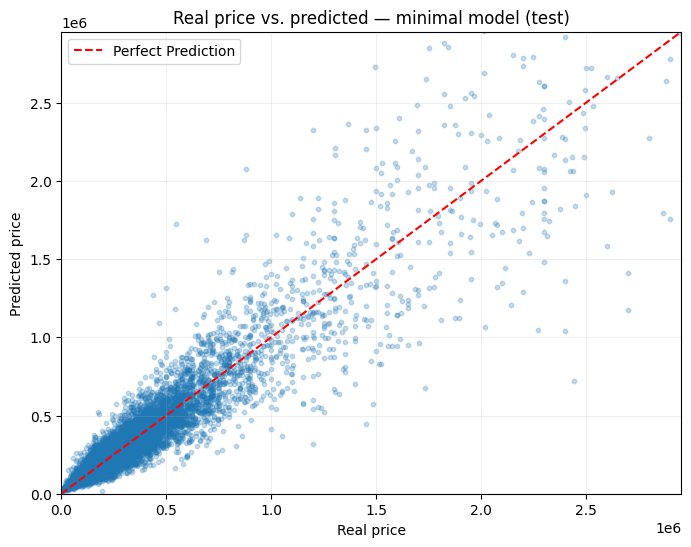

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Real and predicted values from the same test set
y_test_graph = y_test.to_numpy()


rng = np.random.default_rng(42)

indexs = rng.choice(len(y_test_graph),size=min(10_000, len(y_test_graph)),replace=False)

y_test_graph_muestra = y_test_graph[indexs]
y_test_minimal_pred_muestra = (y_test_minimal_pred[indexs])


minimal_limit = min(0,np.quantile(y_test_graph, 0.01),np.quantile(y_test_minimal_pred, 0.01))
maximal_limit = max(np.quantile(y_test_graph, 0.99),np.quantile(y_test_minimal_pred, 0.99))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_graph_muestra,y_test_minimal_pred_muestra,alpha=0.25,s=10)
plt.plot([minimal_limit, maximal_limit],[minimal_limit, maximal_limit],'--',color='red',label='Perfect Prediction')

plt.xlim(minimal_limit, maximal_limit)
plt.ylim(minimal_limit, maximal_limit)

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title('Real price vs. predicted — minimal model (test)'
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Some metrics 


In [17]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


mae_minimal = mean_absolute_error(y_test,y_test_minimal_pred)
rmse_minimal = mean_squared_error(y_test,y_test_minimal_pred) ** 0.5
r2_minimal = r2_score(y_test,y_test_minimal_pred)

print("MAE:", mae_minimal)
print("RMSE:", rmse_minimal)
print("R²:", r2_minimal)

MAE: 92053.54291999577
RMSE: 413366.6453051061
R²: 0.8960526051394742


## Now lets try with Ridge

In [18]:
from sklearn.linear_model import Ridge

modelo_minimal = Ridge(
    alpha=1.0,
    solver='lsqr'
)

modelo_minimal.fit(X_train_minimal, y_train)

y_test_minimal_pred = modelo_minimal.predict(X_test_minimal)

### Graph with Ridge 

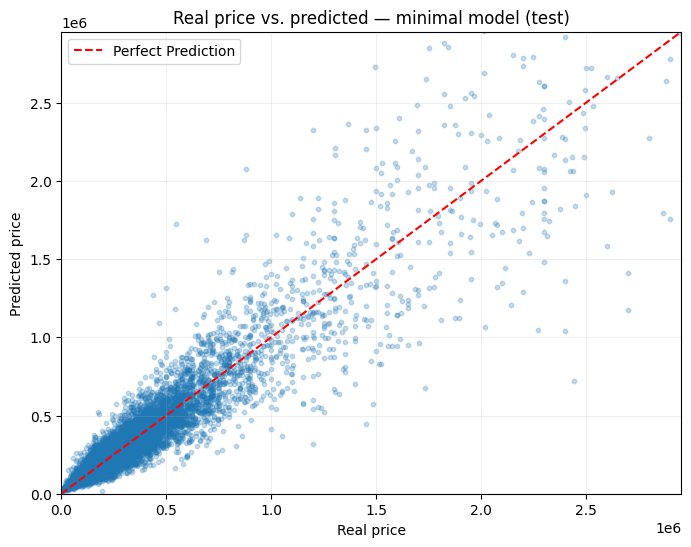

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Real and predicted values from the same test set
y_test_graph = y_test.to_numpy()


rng = np.random.default_rng(42)

indexs = rng.choice(len(y_test_graph),size=min(10_000, len(y_test_graph)),replace=False)

y_test_graph_muestra = y_test_graph[indexs]
y_test_minimal_pred_muestra = (y_test_minimal_pred[indexs])


minimal_limit = min(0,np.quantile(y_test_graph, 0.01),np.quantile(y_test_minimal_pred, 0.01))
maximal_limit = max(np.quantile(y_test_graph, 0.99),np.quantile(y_test_minimal_pred, 0.99))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_graph_muestra,y_test_minimal_pred_muestra,alpha=0.25,s=10)
plt.plot([minimal_limit, maximal_limit],[minimal_limit, maximal_limit],'--',color='red',label='Perfect Prediction')

plt.xlim(minimal_limit, maximal_limit)
plt.ylim(minimal_limit, maximal_limit)

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title('Real price vs. predicted — minimal model (test)'
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Metrics of Ridge

In [20]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


mae_minimal = mean_absolute_error(y_test,y_test_minimal_pred)
rmse_minimal = mean_squared_error(y_test,y_test_minimal_pred) ** 0.5
r2_minimal = r2_score(y_test,y_test_minimal_pred)

print("MAE:", mae_minimal)
print("RMSE:", rmse_minimal)
print("R²:", r2_minimal)

MAE: 92053.54291999577
RMSE: 413366.6453051061
R²: 0.8960526051394742


## Lets start with EDA

In [21]:
print("This is the general structure of the dataset, lets remember")
print("Matrix with features")
X.head()

This is the general structure of the dataset, lets remember
Matrix with features


,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0
5,24038,2024,Deep River,57820.0,Vacant Land,NaN,2025.0,4.0,4.0


Measures of central tendency

Variables of time (List Year, Year Recorded, Month Recorded, Day Recorded)


Variable List Year

Mean of the variable List Year:  2012.0768879002953
Count per year : 
 List Year
2001    45225
2002    46244
2003    49394
2004    65299
2005    48314
2006    36693
2007    24315
2008    21112
2009    27242
2010    20516
2011    19504
2012    23238
2013    25513
2014    31979
2015    30530
2016    32831
2017    30728
2018    34355
2019    42358
2020    52142
2021    44385
2022    32261
2023    32737
2024    35924
Name: count, dtype: int64

Variable Year Recorded

Mean of the variable Year Recorded:  2012.819682322224
Count per year : 
 Year Recorded
1999.0        1
2001.0    10858
2002.0    45880
2003.0    43405
2004.0    57167
2005.0    61873
2006.0    44795
2007.0    34046
2008.0    22830
2009.0    23678
2010.0    24548
2011.0    19722
2012.0    20516
2013.0    24361
2014.0    26671
2015.0    31535
2016.0    31356
2017.0    32175
2018.0    31810
2019.0    360

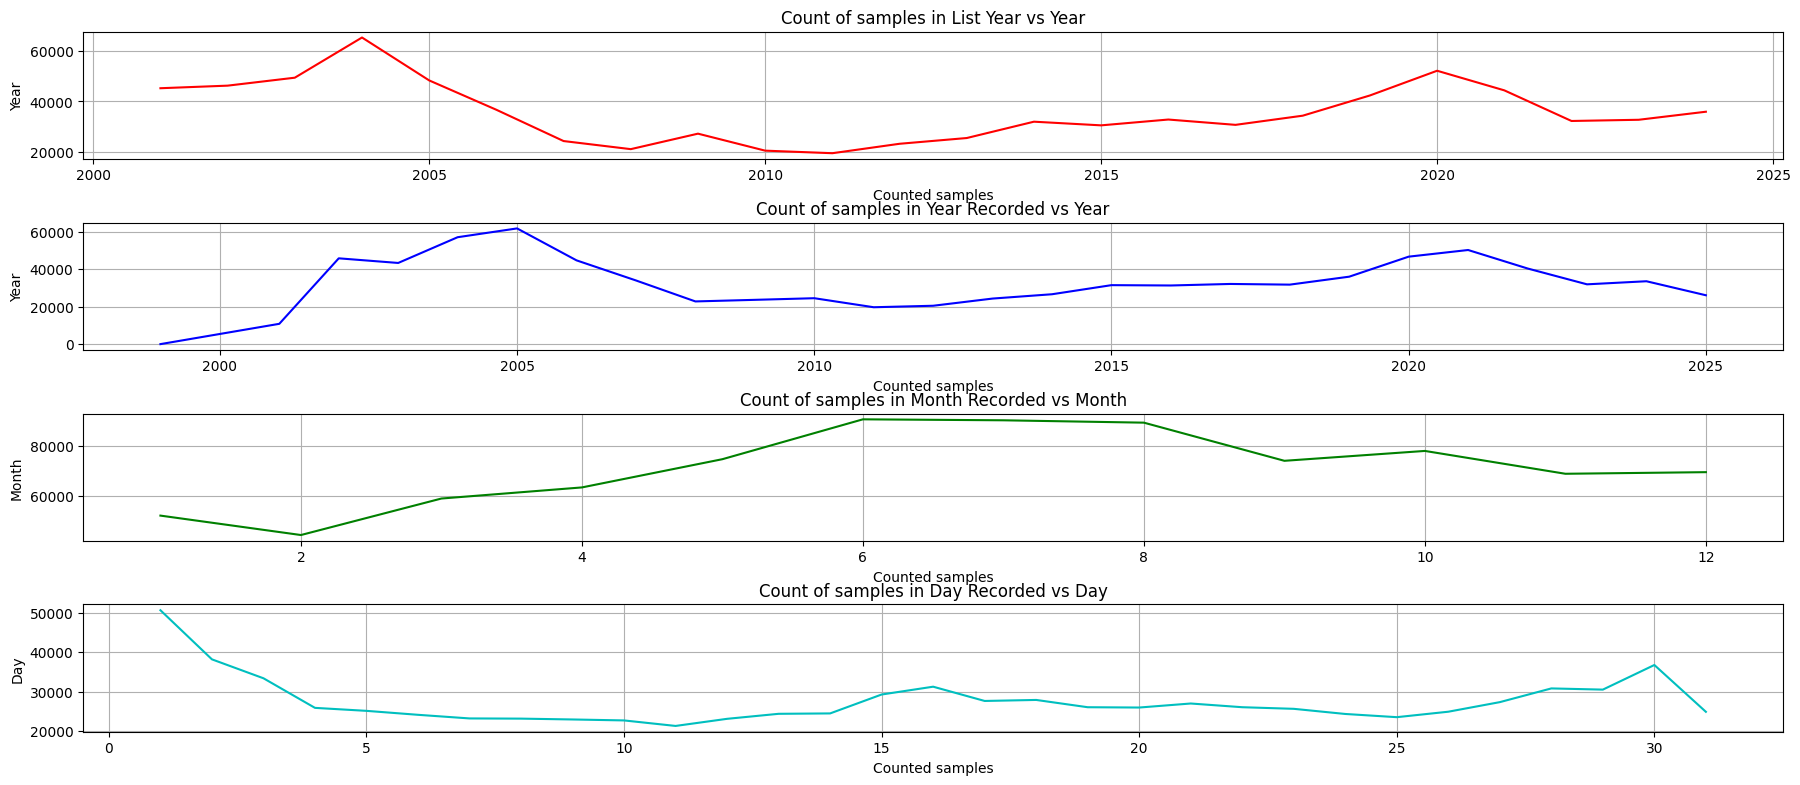

In [22]:
print("Measures of central tendency\n")
print("Variables of time (List Year, Year Recorded, Month Recorded, Day Recorded)\n")


plt.figure(1, [20, 10])


print("\nVariable List Year\n")
print("Mean of the variable List Year: ", X['List Year'].mean())

count_per_year_list_year = X['List Year'].value_counts().sort_index()
print("Count per year : \n", count_per_year_list_year)

plt.subplot(411)
plt.plot(count_per_year_list_year.index, count_per_year_list_year.values,'r') 
plt.title("Count of samples in List Year vs Year")
plt.ylabel("Year")
plt.xlabel("Counted samples")
plt.grid(True)

print("\nVariable Year Recorded\n")
print("Mean of the variable Year Recorded: ", X['Year Recorded'].mean())

count_per_year_year_recorded = X['Year Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_year_recorded)

plt.subplot(412)
plt.plot(count_per_year_year_recorded.index,count_per_year_year_recorded.values, 'b') 
plt.title("Count of samples in Year Recorded vs Year")
plt.ylabel("Year")
plt.xlabel("Counted samples")
plt.grid(True)

print("\nVariable Month Recorded\n")
print("Mean of the variable Year Recorded: ", X['Year Recorded'].mean())

count_per_year_month_recorded = X['Month Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_month_recorded)

plt.subplot(413)
plt.plot(count_per_year_month_recorded.index,count_per_year_month_recorded.values, 'g') 
plt.title("Count of samples in Month Recorded vs Month")
plt.ylabel("Month")
plt.xlabel("Counted samples")
plt.grid(True)


print("\nVariable Day Recorded\n")
print("Mean of the variable Day Recorded: ", X['Day Recorded'].mean())

count_per_year_day_recorded = X['Day Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_day_recorded)

plt.subplot(414)
plt.plot(count_per_year_day_recorded.index,count_per_year_day_recorded.values, 'c') 
plt.title("Count of samples in Day Recorded vs Day")
plt.ylabel("Day")
plt.xlabel("Counted samples")
plt.grid(True)

plt.subplots_adjust(top=0.9, bottom=0.2, left=0.10, right=0.95, hspace=0.5, wspace=1)
plt.show()


### Categorical classes

In [23]:
X.head()

,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0
5,24038,2024,Deep River,57820.0,Vacant Land,NaN,2025.0,4.0,4.0


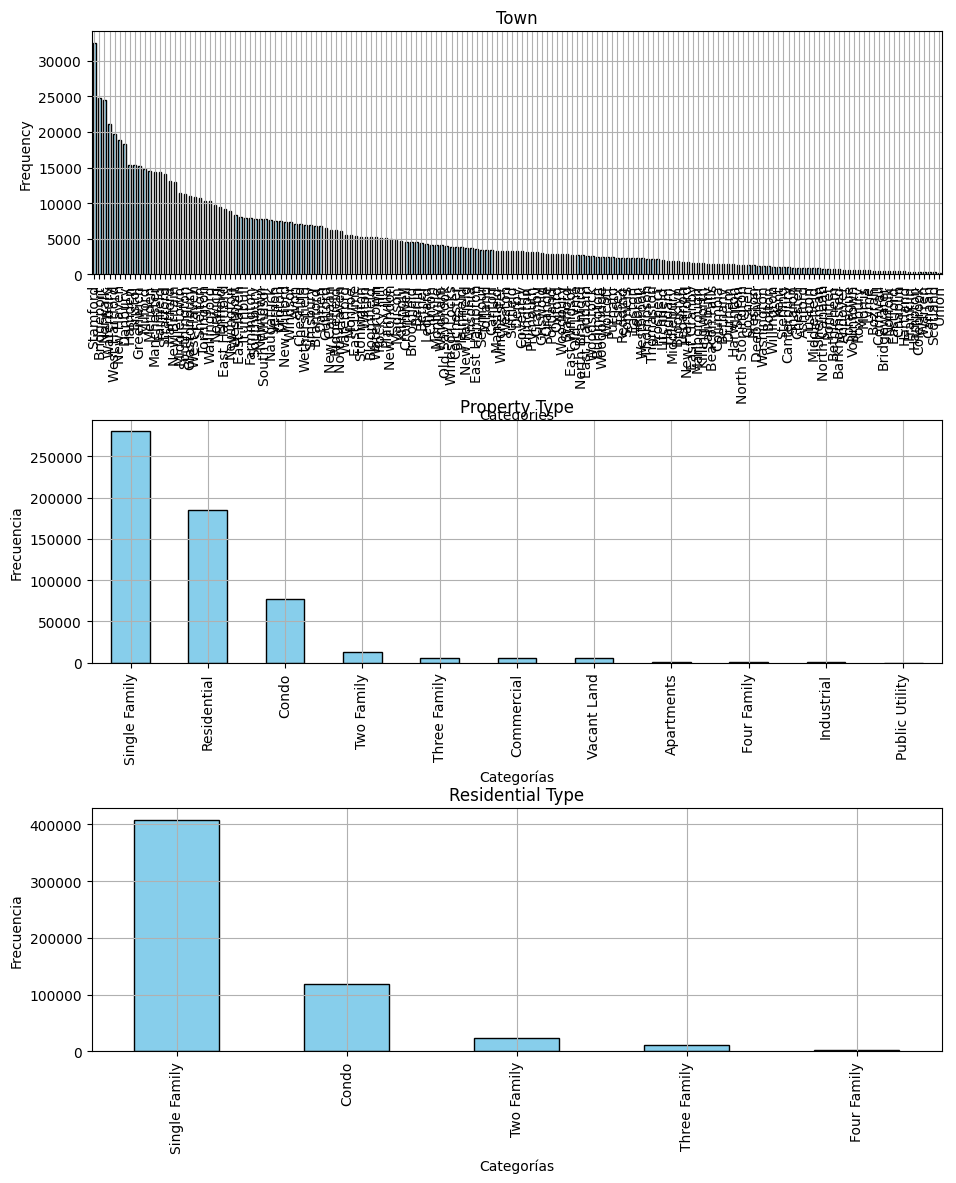

In [24]:
plt.figure(1, figsize=(10, 12))


plt.subplot(311)
X['Town'].value_counts().plot.bar(edgecolor='black', color='skyblue')
plt.title('Town')
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(312) 
X['Property Type'].value_counts().plot.bar(edgecolor='black', color='skyblue')
plt.title('Property Type')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.grid(True)

plt.subplot(313)  
X['Residential Type'].value_counts().plot.bar(edgecolor='black', color='skyblue')
plt.title('Residential Type')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.grid(True)

plt.subplots_adjust(top=0.95, bottom=0.1, left=0.10, right=0.95, hspace=0.6, wspace=1)


plt.show()


Now we have to apply binary encoding for the feature 'Town', due to its high cardinality.
The rest of the categorical features can be one-hot encoded.

## Measures of dispersion

In [25]:
X.head()

,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0
5,24038,2024,Deep River,57820.0,Vacant Land,NaN,2025.0,4.0,4.0


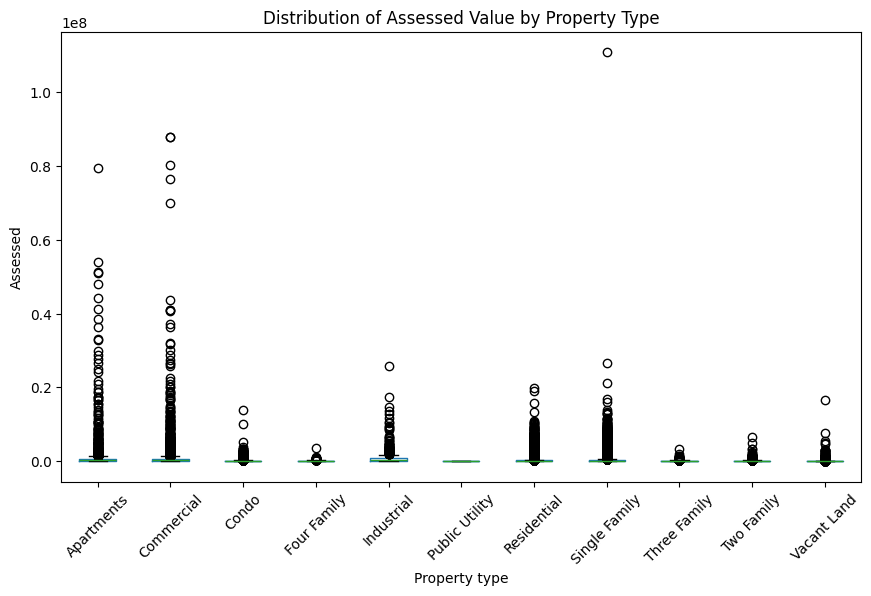

In [26]:
X.boxplot(column='Assessed Value', by='Property Type', figsize=(10, 6), grid=False)
plt.title('Distribution of Assessed Value by Property Type')
plt.suptitle('')
plt.xlabel('Property type')
plt.ylabel('Assessed')
plt.xticks(rotation=45) 
plt.show()

In [27]:
# Look for values above 800 million
outliers_extremos = X[X['Assessed Value'] > 800_000_000]
print(outliers_extremos[['Property Type', 'Assessed Value']])



Empty DataFrame
Columns: [Property Type, Assessed Value]
Index: []


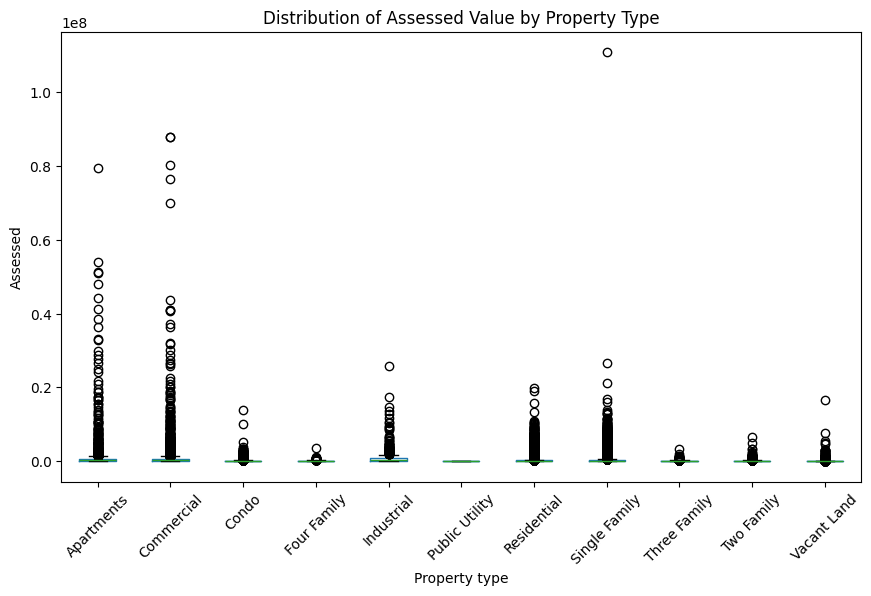

In [28]:
X.boxplot(column='Assessed Value', by='Property Type', figsize=(10, 6), grid=False)
plt.title('Distribution of Assessed Value by Property Type')
plt.suptitle('')
plt.xlabel('Property type')
plt.ylabel('Assessed')
plt.xticks(rotation=45) 
plt.show()

This is a clear symptom, our dataset has a right-skewed distribution then we would have to apply a logaritmic transformation so we compact the data 

In [29]:
X.head()

,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0
5,24038,2024,Deep River,57820.0,Vacant Land,NaN,2025.0,4.0,4.0


## Boxplot for Residential Type

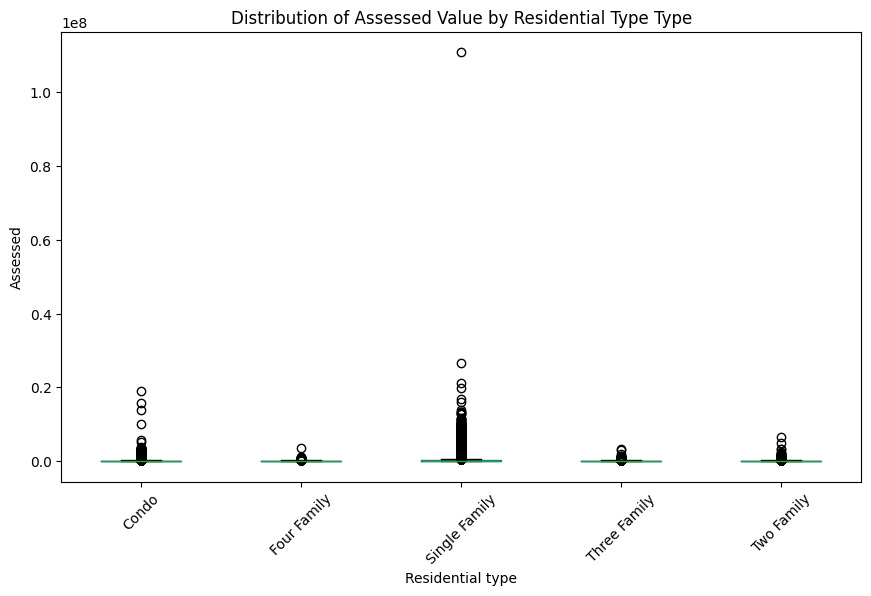

In [30]:
X.boxplot(column='Assessed Value', by='Residential Type', figsize=(10, 6), grid=False)
plt.title('Distribution of Assessed Value by Residential Type Type')
plt.suptitle('')
plt.xlabel('Residential type')
plt.ylabel('Assessed')
plt.xticks(rotation=45) 
plt.show()

Again the same pattern this combination has a right-skewed distribution, so we got to apply log transformation latter

In [31]:
X.head()

y.head()

0     95000.0
2    480000.0
3     15000.0
4    179900.0
5     50000.0
Name: Sale Amount, dtype: float64

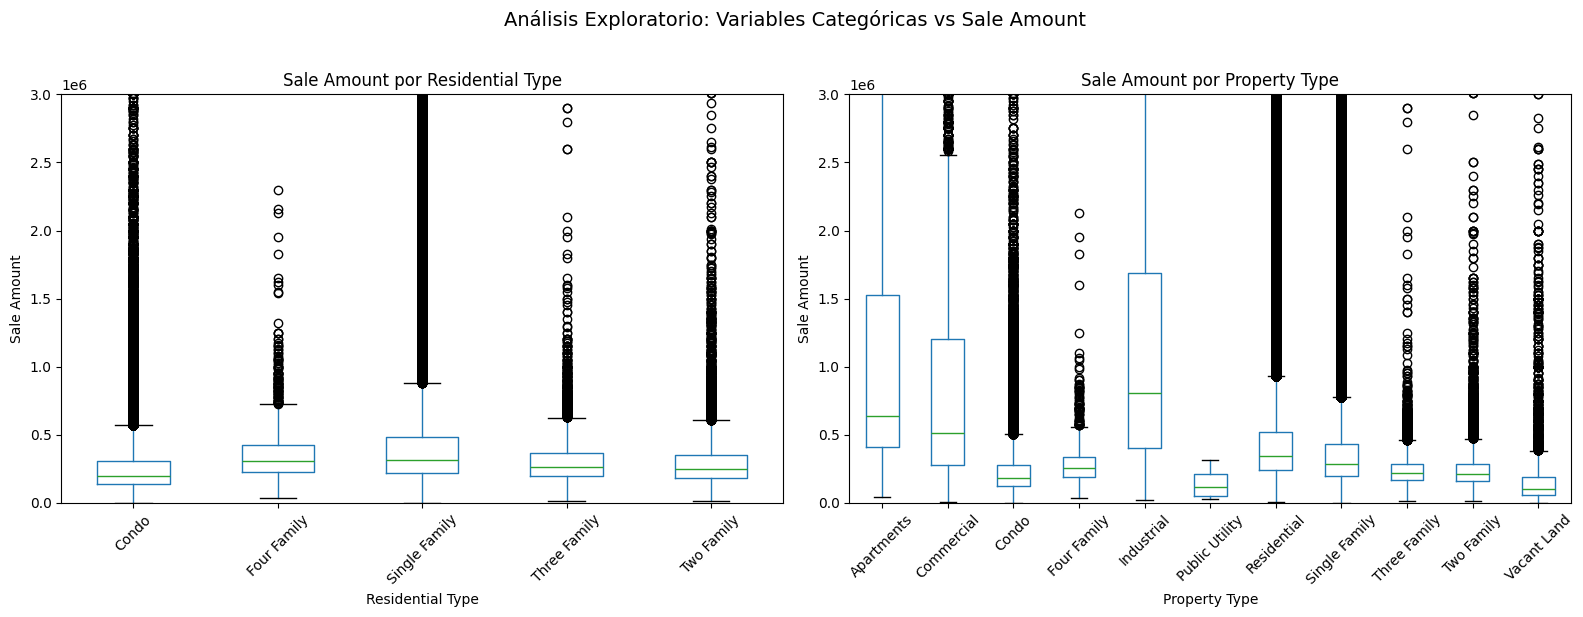

In [32]:

df_temporal = X[['Residential Type', 'Property Type']].copy()
df_temporal['Sale Amount'] = y


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


df_temporal.boxplot(column='Sale Amount', by='Residential Type', ax=axes[0], grid=False)
axes[0].set_title('Sale Amount por Residential Type')
axes[0].set_xlabel('Residential Type')
axes[0].set_ylabel('Sale Amount')
axes[0].tick_params(axis='x', rotation=45)


axes[0].set_ylim(0, 3_000_000) 


df_temporal.boxplot(column='Sale Amount', by='Property Type', ax=axes[1], grid=False)
axes[1].set_title('Sale Amount por Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Sale Amount')
axes[1].tick_params(axis='x', rotation=45)

axes[1].set_ylim(0, 3_000_000) 

plt.suptitle('Análisis Exploratorio: Variables Categóricas vs Sale Amount', fontsize=14, y=1.02)
plt.tight_layout()

plt.show()


## Quantiles

In [33]:
df_concat = pd.concat([X, y] , axis=1)

general_quantiles1 = df_concat['Assessed Value'].quantile([0.25, 0.5, 0.75])
general_quantiles2 = df_concat['Sale Amount'].quantile([0.25, 0.5, 0.75])

iqr1 = general_quantiles1.loc[0.75] - general_quantiles1.loc[0.25]
iqr2 = general_quantiles2.loc[0.75] - general_quantiles2.loc[0.25]

print("General quantiles of Assessed Value")
print(general_quantiles1)
print(f"The IQR is: ${iqr1:,.2f}")

print("General quantiles of Sale Amount")
print(general_quantiles2)
print(f"The IQR is: ${iqr2:,.2f}")

General quantiles of Assessed Value
0.25     96780.0
0.50    150220.0
0.75    240660.0
Name: Assessed Value, dtype: float64
The IQR is: $143,880.00
General quantiles of Sale Amount
0.25    175000.0
0.50    265000.0
0.75    414000.0
Name: Sale Amount, dtype: float64
The IQR is: $239,000.00


In [34]:

quantiles_property_assessed_value = df_concat.groupby('Property Type')['Assessed Value'].agg([
    ('p25', lambda x: x.quantile(0.25)),
    ('p50', lambda x: x.quantile(0.5)),
    ('p75', lambda x: x.quantile(0.75)),
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
])

print("These are the quantiles for the variable Assessed Value in each property Type")

quantiles_property_assessed_value.style.format('${:,.2f}')

These are the quantiles for the variable Assessed Value in each property Type


,p25,p50,p75,iqr
Property Type,,,,
Apartments,"$185,555.00","$283,210.00","$658,140.00","$472,585.00"
Commercial,"$166,780.00","$296,010.00","$639,940.00","$473,160.00"
Condo,"$83,230.00","$121,170.00","$186,440.00","$103,210.00"
Four Family,"$123,090.00","$155,490.00","$205,210.00","$82,120.00"
Industrial,"$200,360.00","$420,070.00","$868,490.00","$668,130.00"
Public Utility,"$85,445.00","$109,780.00","$128,327.50","$42,882.50"
Residential,"$119,700.00","$173,300.00","$268,865.00","$149,165.00"
Single Family,"$135,030.00","$190,330.00","$294,677.50","$159,647.50"
Three Family,"$86,520.00","$125,125.00","$170,152.50","$83,632.50"


In [35]:
quantiles_residential_assessed_value = df_concat.groupby('Residential Type')['Assessed Value'].agg([
    ('p25', lambda x: x.quantile(0.25)),
    ('p50', lambda x: x.quantile(0.5)),
    ('p75', lambda x: x.quantile(0.75)),
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
])


print("These are the quantiles for the variable Assessed Value in each Residential Type")

quantiles_residential_assessed_value.style.format('${:,.2f}')

These are the quantiles for the variable Assessed Value in each Residential Type


,p25,p50,p75,iqr
Residential Type,,,,
Condo,"$81,190.00","$120,120.00","$187,950.00","$106,760.00"
Four Family,"$126,865.00","$164,740.00","$222,067.50","$95,202.50"
Single Family,"$136,360.00","$191,790.00","$298,270.00","$161,910.00"
Three Family,"$93,170.00","$132,180.00","$185,297.50","$92,127.50"
Two Family,"$101,640.00","$137,500.00","$186,900.00","$85,260.00"


In [36]:
quantiles_property_sale_amount = df_concat.groupby('Property Type')['Sale Amount'].agg([
    ('p25', lambda x: x.quantile(0.25)),
    ('p50', lambda x: x.quantile(0.5)),
    ('p75', lambda x: x.quantile(0.75)),
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
])

print("These are the quantiles for the variable Sale Amount in each property Type")

quantiles_property_sale_amount.style.format('${:,.2f}')

These are the quantiles for the variable Sale Amount in each property Type


,p25,p50,p75,iqr
Property Type,,,,
Apartments,"$408,250.00","$640,000.00","$1,527,500.00","$1,119,250.00"
Commercial,"$280,000.00","$510,000.00","$1,200,000.00","$920,000.00"
Condo,"$125,000.00","$180,000.00","$276,500.00","$151,500.00"
Four Family,"$190,000.00","$255,000.00","$340,000.00","$150,000.00"
Industrial,"$400,000.00","$805,000.00","$1,691,317.00","$1,291,317.00"
Public Utility,"$52,462.50","$119,975.00","$213,750.00","$161,287.50"
Residential,"$242,500.00","$346,000.00","$517,000.00","$274,500.00"
Single Family,"$200,000.00","$284,000.00","$431,000.00","$231,000.00"
Three Family,"$170,000.00","$220,000.00","$285,600.00","$115,600.00"


In [37]:
quantiles_residential_sale_amount = df_concat.groupby('Residential Type')['Sale Amount'].agg([
    ('p25', lambda x: x.quantile(0.25)),
    ('p50', lambda x: x.quantile(0.5)),
    ('p75', lambda x: x.quantile(0.75)),
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
])


print("These are the quantiles for the variable Assessed Value in each Residential Type")

quantiles_residential_sale_amount.style.format('${:,.2f}')

These are the quantiles for the variable Assessed Value in each Residential Type


,p25,p50,p75,iqr
Residential Type,,,,
Condo,"$135,000.00","$199,900.00","$309,000.00","$174,000.00"
Four Family,"$224,250.00","$307,870.00","$425,000.00","$200,750.00"
Single Family,"$220,000.00","$315,000.00","$485,000.00","$265,000.00"
Three Family,"$195,000.00","$265,000.00","$368,000.00","$173,000.00"
Two Family,"$180,000.00","$250,000.00","$350,000.00","$170,000.00"


Looking at the IQR by `Property Type`, there is high variability in the `Sale Amount`, especially in the commercial-oriented categories. Industrial (\$1,291,317) and Apartments (\$1,119,250) have interquartile ranges above a million, with Commercial close behind (\$920,000).

The rest of the categories show smaller IQRs, but they are still considerable: Residential (\$274,500) and Single Family (\$231,000) are in the same order of magnitude as the general IQR. This means that even within a single property type, prices vary a lot across the dataset.

The general IQR for `Sale Amount` is \$239,000 (median \$265,000), which is actually smaller than the IQR of several individual categories. This happens because the residential categories make up most of the records, so the global quartiles mostly reflect them, while the commercial categories sit in the upper tail.

The same pattern appears in `Assessed Value`, but on a smaller scale (general IQR of \$143,880), which is expected since assessed values are typically below sale prices.

Because of this, a model would likely have more trouble predicting the `Sale Amount` for Apartments, Commercial and Industrial properties, since their values are spread over a much wider range than the rest.

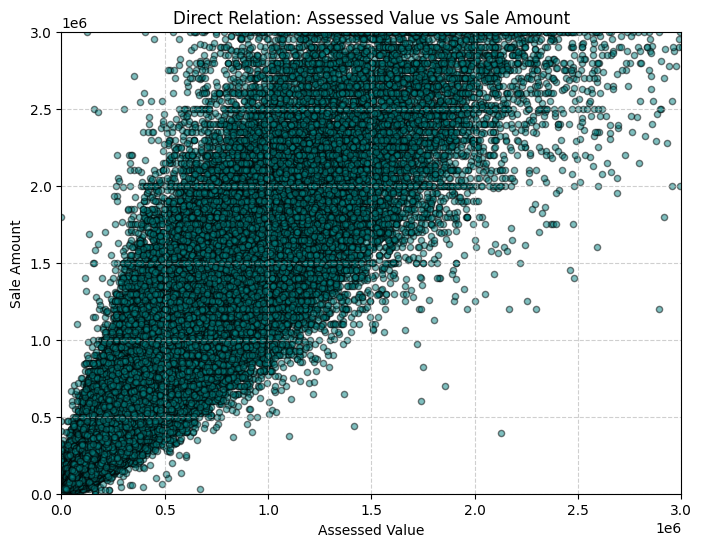

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(X['Assessed Value'], y, alpha=0.5, color='teal', edgecolor='k', s=20)

plt.title('Direct Relation: Assessed Value vs Sale Amount')
plt.xlabel('Assessed Value')
plt.ylabel('Sale Amount')

plt.xlim(0, 3_000_000)
plt.ylim(0, 3_000_000)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Lets delete symbolic sales, it doesn't help much with our porpouse

Valid comercial registers: 851689
Deleted noisy registers: 1150


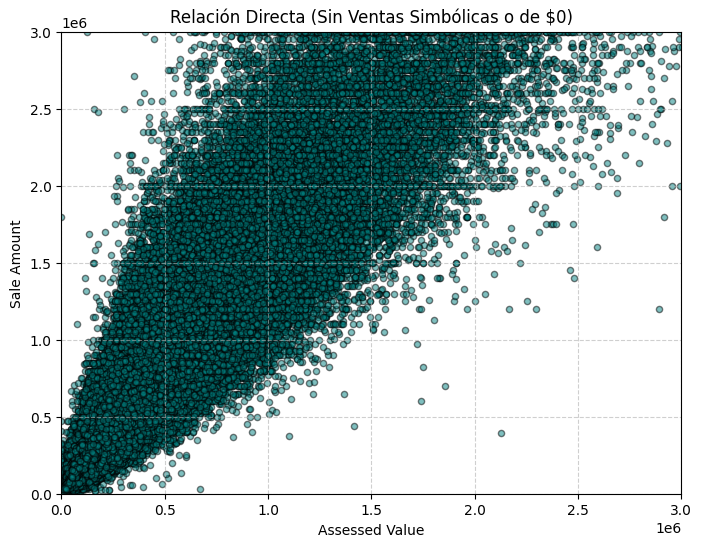

In [39]:
umbral_minimo = 10000

mascara_comercial = y > umbral_minimo

X_filtrado = X[mascara_comercial].copy()
y_filtrado = y[mascara_comercial].copy()

registros_eliminados = len(y) - len(y_filtrado)
print(f"Valid comercial registers: {len(y_filtrado)}")
print(f"Deleted noisy registers: {registros_eliminados}")

plt.figure(figsize=(8, 6))
plt.scatter(X_filtrado['Assessed Value'], y_filtrado, alpha=0.5, color='teal', edgecolor='k', s=20)

plt.title('Relación Directa (Sin Ventas Simbólicas o de $0)')
plt.xlabel('Assessed Value')
plt.ylabel('Sale Amount')

plt.xlim(0, 3_000_000)
plt.ylim(0, 3_000_000)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


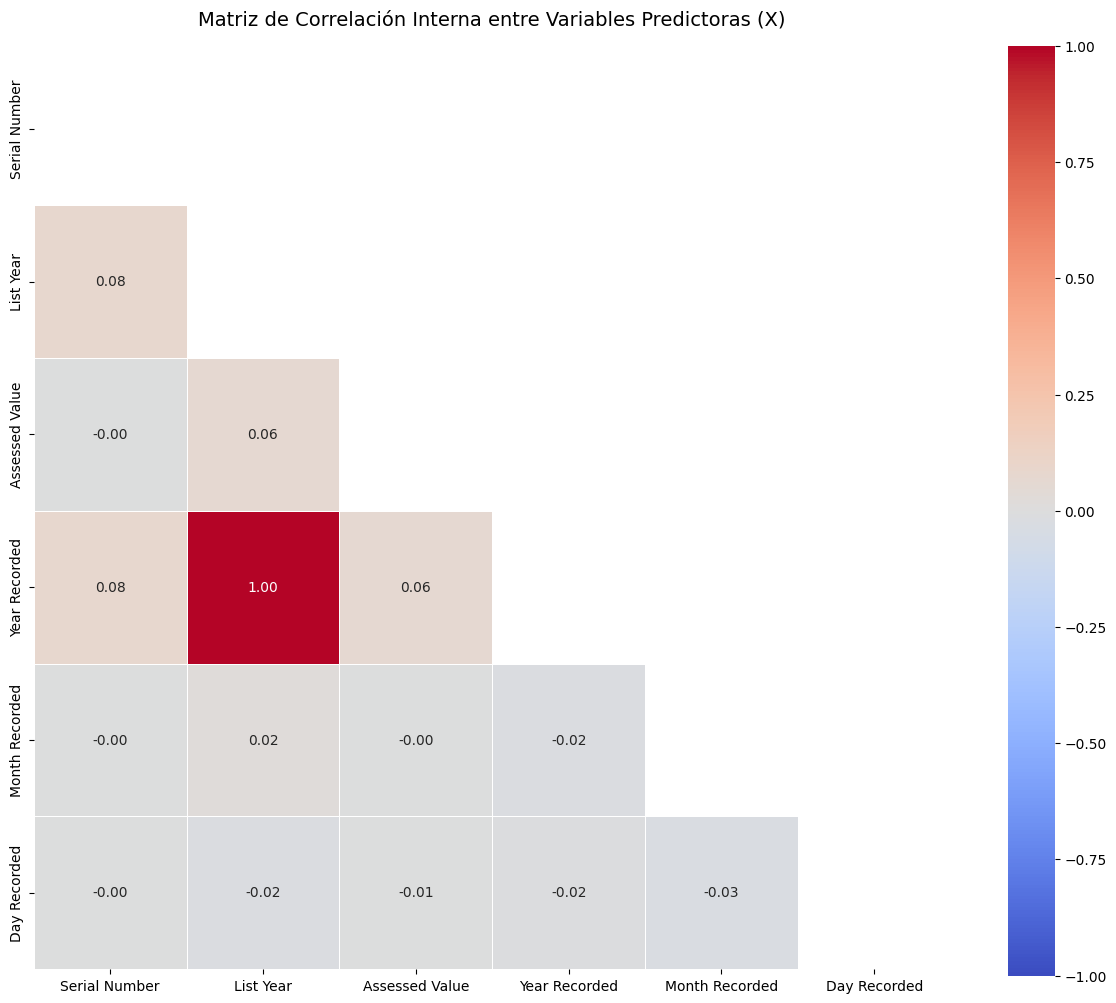

In [40]:
import seaborn as sns


X_numericas = X.select_dtypes(include=[np.number])
matriz_corr_interna = X_numericas.corr()

plt.figure(figsize=(12, 10))
mascara = np.triu(np.ones_like(matriz_corr_interna, dtype=bool))


sns.heatmap(matriz_corr_interna, 
            mask=mascara,      
            annot=True,          
            fmt=".2f",           
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True)  

plt.title('Matriz de Correlación Interna entre Variables Predictoras (X)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


We can see that `Year Recorded` and `List Year` have a perfect correlation. We need to drop one of the columns.

## Categorical variable distributions and relationship with price

This section analyzes the frequency of categories in `Residential Type` and `Property Type`. It also compares the distribution of `Sale Amount` across categories using boxplots.

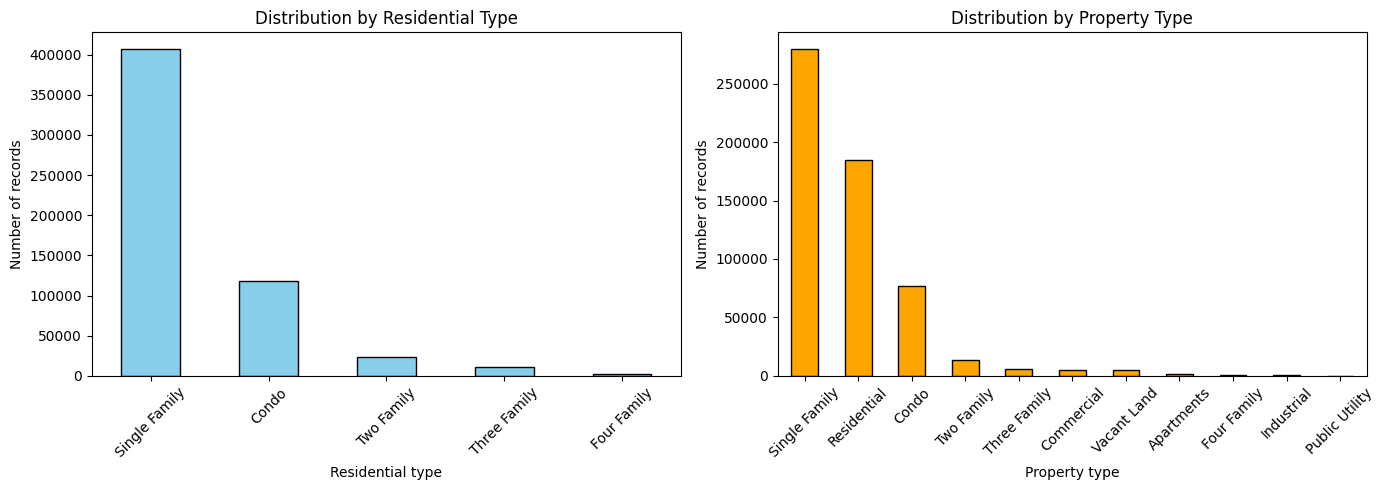

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Category counts, excluding missing values
residential_counts = data['Residential Type'].dropna().value_counts()
property_counts = data['Property Type'].dropna().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residential_counts.plot(
    kind='bar', ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title('Distribution by Residential Type')
axes[0].set_xlabel('Residential type')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=45)

property_counts.plot(
    kind='bar', ax=axes[1], color='orange', edgecolor='black'
)
axes[1].set_title('Distribution by Property Type')
axes[1].set_xlabel('Property type')
axes[1].set_ylabel('Number of records')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

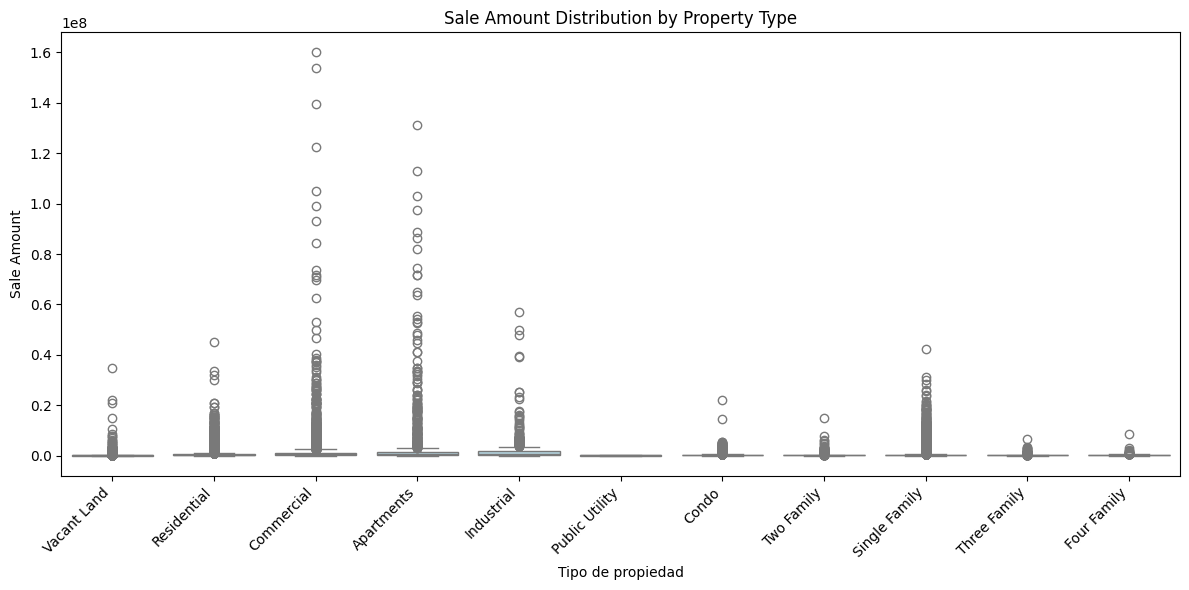

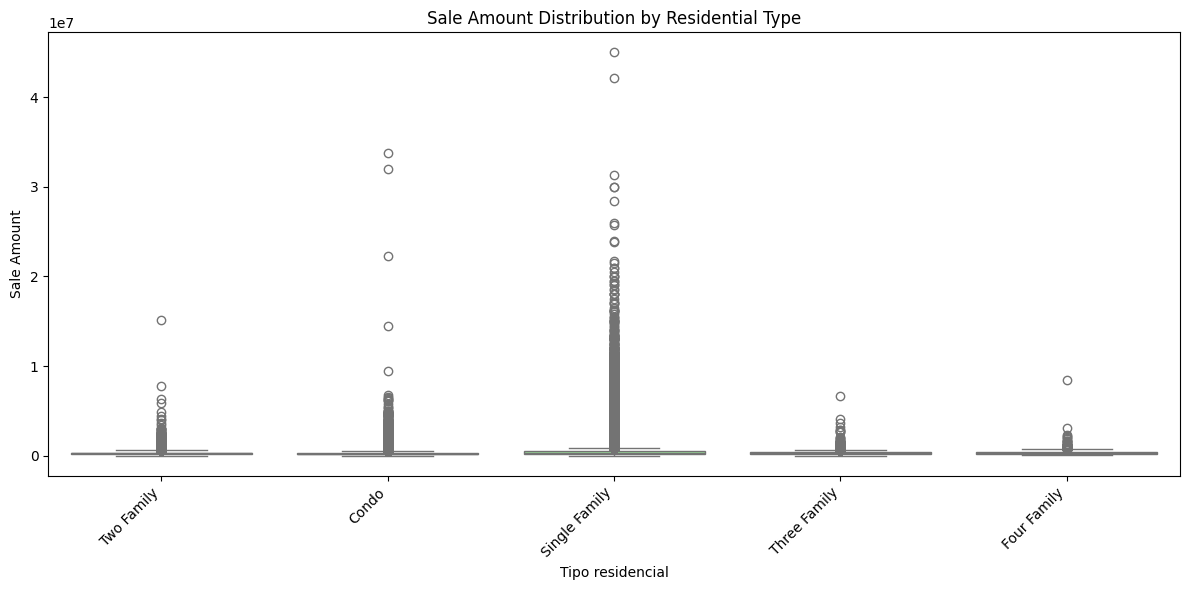

In [42]:
# Compare price distribution by property type
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Property Type', y='Sale Amount', color='lightblue')
plt.title('Sale Amount Distribution by Property Type')
plt.xlabel('Tipo de propiedad')
plt.ylabel('Sale Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Compare price distribution by residential type
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Residential Type', y='Sale Amount', color='lightgreen')
plt.title('Sale Amount Distribution by Residential Type')
plt.xlabel('Tipo residencial')
plt.ylabel('Sale Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As we can see, each boxplot has some really high outliers. This gives us a clue that we need to apply a `RobustScaler()` for standardizing the data.

## Correlation with Sale Amount and multicollinearity

In [43]:

numeric_data = data.select_dtypes(include=np.number).drop(columns=['Sales Ratio'], errors='ignore').copy()
correlation_with_target = numeric_data.corr(method='spearman')['Sale Amount'].drop('Sale Amount').sort_values(key=abs, ascending=False)
display(correlation_with_target.to_frame('Spearman with Sale Amount'))


def eta_squared(category, target):
    frame = pd.DataFrame({'category': category, 'target': target}).dropna()
    overall_mean = frame['target'].mean()
    grouped = frame.groupby('category', observed=True)['target']
    numerator = (grouped.size() * (grouped.mean() - overall_mean) ** 2).sum()
    denominator = ((frame['target'] - overall_mean) ** 2).sum()
    return numerator / denominator if denominator else 0

categorical_data = data.select_dtypes(include=['object', 'category', 'bool'])
eta_with_target = pd.Series({column: eta_squared(data[column], data['Sale Amount']) for column in categorical_data.columns}).sort_values(ascending=False)
display(eta_with_target.to_frame('Eta squared with Sale Amount'))

,Spearman with Sale Amount
Assessed Value,0.909650
Year Recorded,0.236433
List Year,0.235123
Serial Number,0.173868
Month Recorded,0.010009
Day Recorded,-0.009882


,Eta squared with Sale Amount
Sales Ratio,0.575789
Town,0.075798
Property Type,0.043456
Residential Type,0.025343


We can see that the `Assessed Value` has the highest correlation with `Sale Amount`. This variable will most likely be the most important one for the model in terms of predicting our target value. The next variables that follow are `List Year` and `Year Recorded`. Let's remember that both of these variables have a perfect correlation, so we are going to get rid of one.

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.select_dtypes(include=np.number).drop(columns=['Sale Amount'], errors='ignore').copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.loc[:, X_vif.nunique(dropna=True) > 1]
X_vif = X_vif.fillna(X_vif.median())

vif_table = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
display(vif_table)
print('VIF < 5: generally acceptable | 5-10: review | > 10: strong multicollinearity')

,Variable,VIF
1,List Year,3.182893e+07
3,Year Recorded,3.180740e+07
4,Month Recorded,1.015974e+01
5,Day Recorded,3.790144e+00
2,Assessed Value,1.124751e+00
0,Serial Number,1.006001e+00


VIF < 5: generally acceptable | 5-10: review | > 10: strong multicollinearity


Same pattern: `List Year` and `Year Recorded` are being explained by each other, that's why VIF is high for each other.

## Visualization of correlations, associations, and VIF

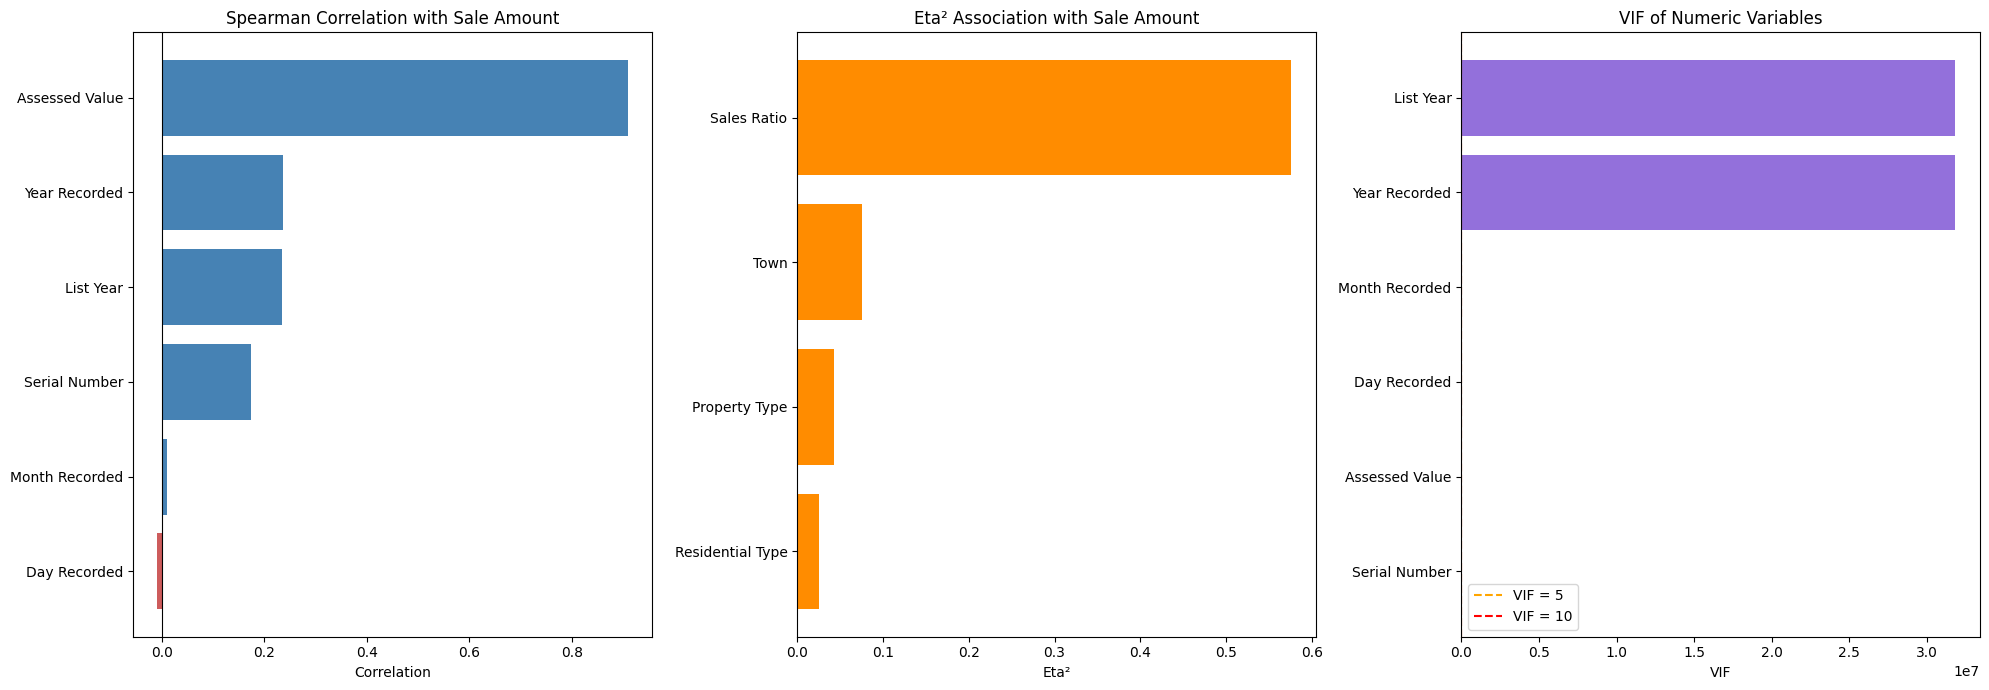

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

numeric_plot = correlation_with_target.sort_values()
axes[0].barh(numeric_plot.index, numeric_plot.values, color=np.where(numeric_plot.values >= 0, 'steelblue', 'indianred'))
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Spearman Correlation with Sale Amount')
axes[0].set_xlabel('Correlation')

eta_plot = eta_with_target.sort_values()
axes[1].barh(eta_plot.index, eta_plot.values, color='darkorange')
axes[1].set_title('Eta² Association with Sale Amount')
axes[1].set_xlabel('Eta²')

vif_plot = vif_table.sort_values('VIF')
axes[2].barh(vif_plot['Variable'], vif_plot['VIF'], color='mediumpurple')
axes[2].axvline(5, color='orange', linestyle='--', label='VIF = 5')
axes[2].axvline(10, color='red', linestyle='--', label='VIF = 10')
axes[2].set_title('VIF of Numeric Variables')
axes[2].set_xlabel('VIF')
axes[2].legend()

plt.tight_layout()
plt.show()

## Conclusions about EDA

* **Market-sale population:** The new `Non Use Code` rule removes 336,158 observations, or 28.272401% of the original 1,188,997 rows, and leaves 852,839 transactions. This is consistent with the business goal because coded transactions may not represent normal market conditions. However, the current notebook does not include a controlled unfiltered rerun on the same indices, so a metric change cannot be attributed only to this filter.
* **Monetary distributions and outliers:** `Assessed Value` and `Sale Amount` are strongly right-skewed and contain long upper tails. `Property Type` and `Residential Type` are categorical variables, so skewness should not be attributed to the category labels themselves. These monetary patterns support `log1p` and robust scaling instead of automatically deleting expensive market transactions.
* **Relationship with the target:** `Assessed Value` has the strongest observed monotonic relationship with `Sale Amount` (Spearman approximately 0.9097). `Year Recorded` and `List Year` show weaker target relationships of approximately 0.2364 and 0.2351. The categorical association results suggest that `Town`, `Property Type`, and `Residential Type` may add complementary information, but a high dispersion or association value alone does not prove predictive usefulness.
* **Redundant year information:** `List Year` and `Year Recorded` have Pearson/Spearman correlations of approximately 0.9983/0.9975. Their VIF values are approximately 438.6 when both are retained and fall close to 1 after either one is removed. This supports removing `List Year` and retaining the complete recorded-date representation.
* **Categorical encoding and leakage:** `Town` has high cardinality, which supports Binary Encoding, while the property categories can use One-Hot Encoding. The apparent association of `Sales Ratio` with the target is not used as evidence because this field is calculated from `Sale Amount` and represents target leakage.
* **Effect of the new filter on the outlier cell:** The saved output shows a `KeyError` when the notebook tries to delete index `375213` manually. That row was already removed by the reproducible `Non Use Code` rule. The hardcoded deletion should therefore be removed; statistical outliers that remain should be handled through justified robust techniques rather than row identifiers.


## Experimental Logarithmic Transformation

This experiment compares the original distributions of `Assessed Value` and `Sale Amount` with temporary `log1p` transformations. The original dataset and modeling variables remain unchanged.

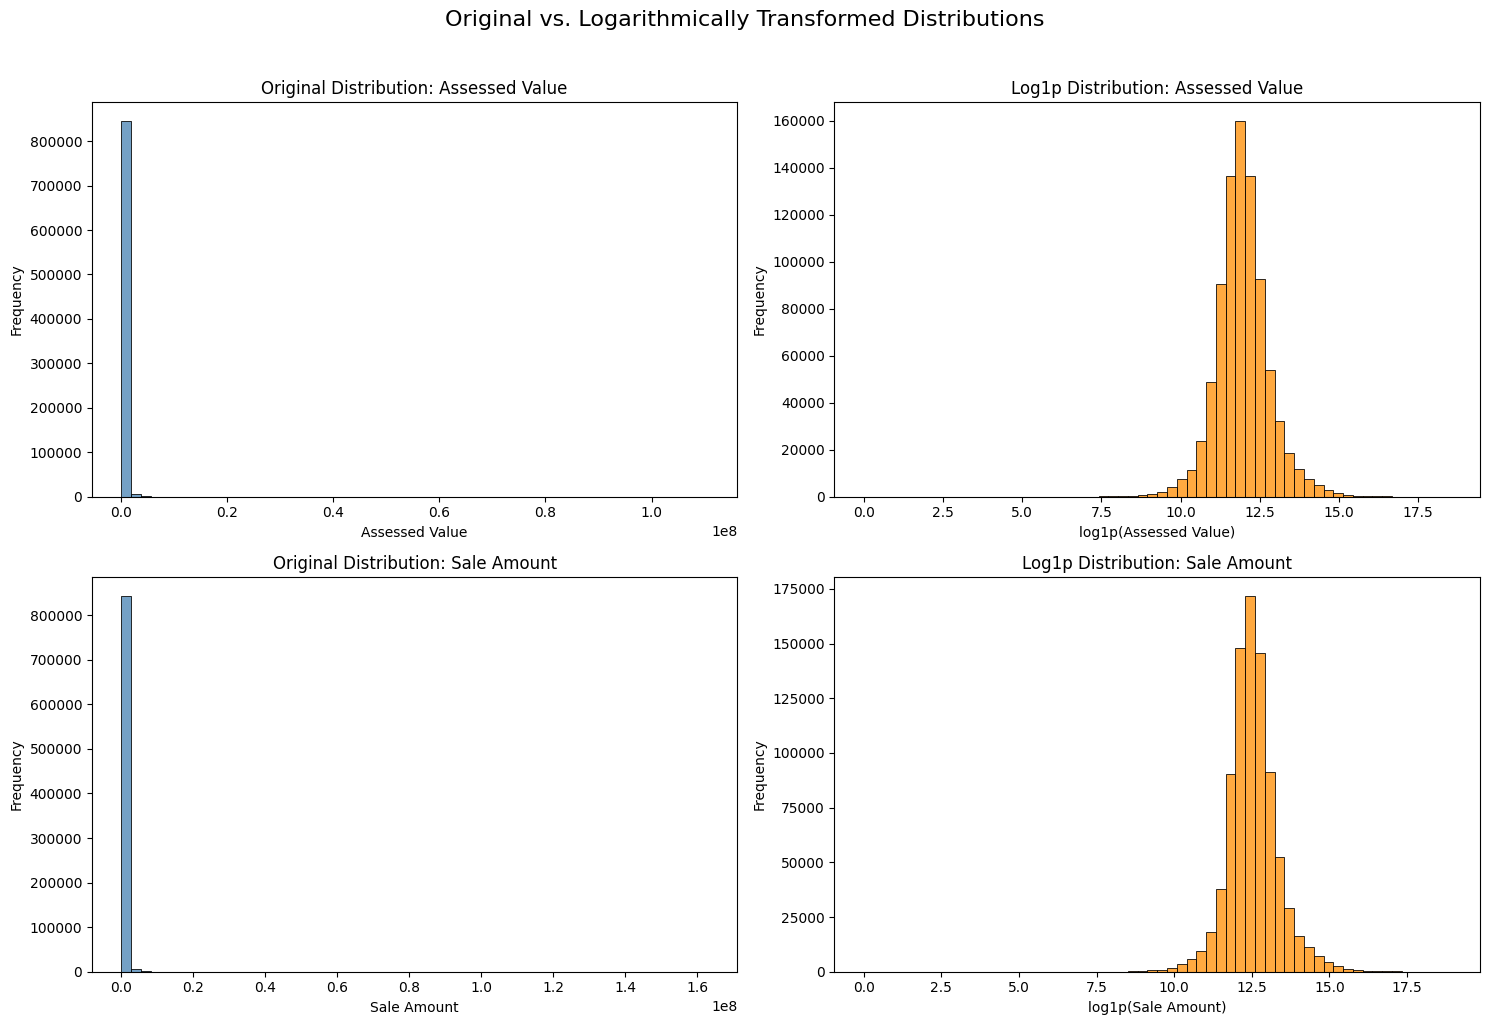

In [46]:
# Create temporary series so the original data remains unchanged
log_experiment_columns = ['Assessed Value', 'Sale Amount']
fig, axes = plt.subplots(len(log_experiment_columns), 2, figsize=(15, 10))

for row, column in enumerate(log_experiment_columns):
    original_values = pd.to_numeric(data[column], errors='coerce').dropna()
    original_values = original_values[original_values >= 0]
    transformed_values = np.log1p(original_values)

    sns.histplot(original_values, bins=60, ax=axes[row, 0], color='steelblue')
    axes[row, 0].set_title(f'Original Distribution: {column}')
    axes[row, 0].set_xlabel(column)
    axes[row, 0].set_ylabel('Frequency')

    sns.histplot(transformed_values, bins=60, ax=axes[row, 1], color='darkorange')
    axes[row, 1].set_title(f'Log1p Distribution: {column}')
    axes[row, 1].set_xlabel(f'log1p({column})')
    axes[row, 1].set_ylabel('Frequency')

plt.suptitle('Original vs. Logarithmically Transformed Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

We can see that the log transformation makes data look less skewed. On the right-hand side, we can see that we had a strongly right-skewed distribution. On the left side, after applying the `log1p` transformation, we can see more evenly distributed values.

## Hypothesis: List Year and Year Recorded May Be Redundant

The extremely high VIF values suggest that `List Year` and `Year Recorded` may explain almost the same temporal information. The following experiments test this hypothesis without modifying the original feature matrix.

In [47]:
# Compare both year variables using only rows where both values are available
year_comparison = X[['List Year', 'Year Recorded']].dropna().copy()
year_comparison['Year Difference'] = (
    year_comparison['List Year'] - year_comparison['Year Recorded']
)

pearson_years = year_comparison['List Year'].corr(
    year_comparison['Year Recorded'], method='pearson'
)
spearman_years = year_comparison['List Year'].corr(
    year_comparison['Year Recorded'], method='spearman'
)
same_year_percentage = (
    year_comparison['Year Difference'].eq(0).mean() * 100
)

year_summary = pd.DataFrame({
    'Metric': [
        'Pearson correlation',
        'Spearman correlation',
        'Rows with the same year (%)'
    ],
    'Value': [pearson_years, spearman_years, same_year_percentage]
})
display(year_summary)
display(
    year_comparison['Year Difference']
    .value_counts()
    .sort_index()
    .rename('Frequency')
    .to_frame()
)

,Metric,Value
0,Pearson correlation,0.998286
1,Spearman correlation,0.997525
2,Rows with the same year (%),25.334345


,Frequency
Year Difference,
-3.0,1
-2.0,2
-1.0,636526
0.0,215991
1.0,10
2.0,12
3.0,5
4.0,1
5.0,5


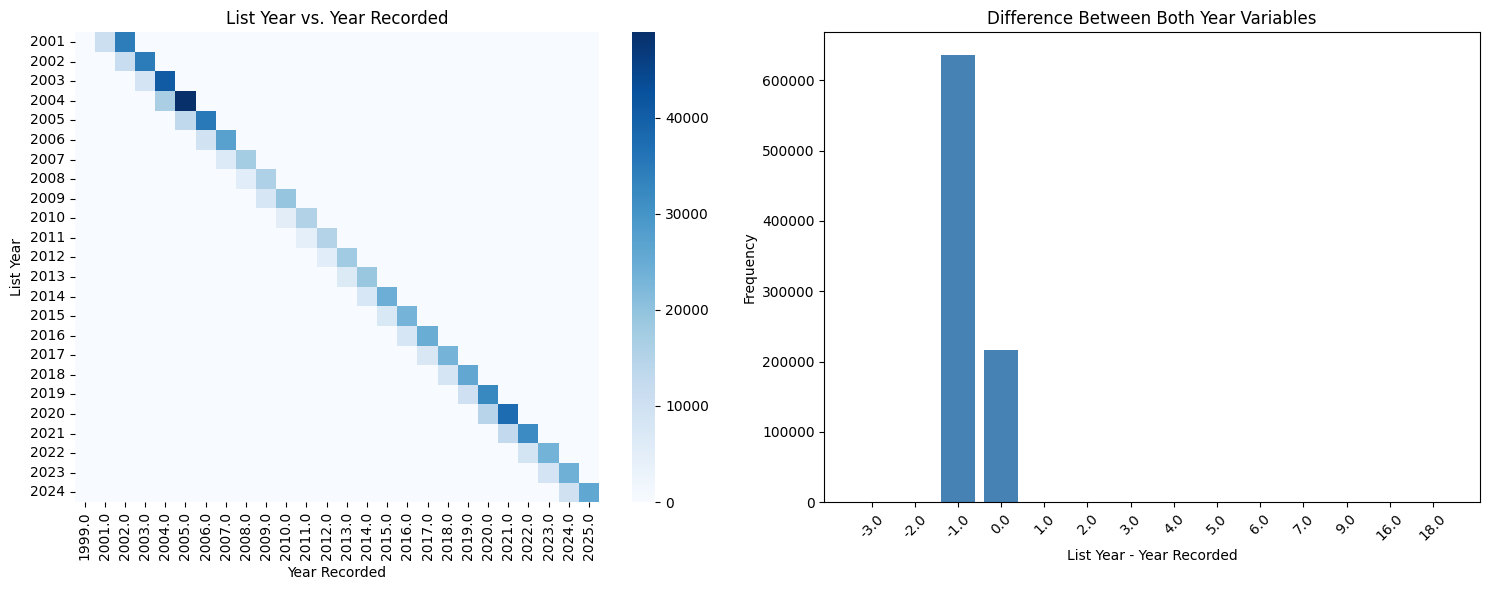

In [48]:
# Visualize whether both variables contain nearly identical year information
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

year_cross_table = pd.crosstab(
    year_comparison['List Year'],
    year_comparison['Year Recorded']
)
sns.heatmap(year_cross_table, cmap='Blues', ax=axes[0])
axes[0].set_title('List Year vs. Year Recorded')
axes[0].set_xlabel('Year Recorded')
axes[0].set_ylabel('List Year')

difference_counts = (
    year_comparison['Year Difference'].value_counts().sort_index()
)
axes[1].bar(
    difference_counts.index.astype(str),
    difference_counts.values,
    color='steelblue'
)
axes[1].set_title('Difference Between Both Year Variables')
axes[1].set_xlabel('List Year - Year Recorded')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

It is common that the List Year and Recorded Year coincide in the same year, so this strengthens the previous hypothesis that both variables contribute the same information to the model

In [49]:
from statsmodels.tools.tools import add_constant

def calculate_vif_with_constant(features):
    numeric_features = features.select_dtypes(include=np.number).copy()
    numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan)
    numeric_features = numeric_features.dropna(axis=1, how='all')
    numeric_features = numeric_features.loc[
        :, numeric_features.nunique(dropna=True) > 1
    ]
    numeric_features = numeric_features.fillna(numeric_features.median())
    numeric_features = add_constant(numeric_features, has_constant='add')

    result = pd.DataFrame({
        'Variable': numeric_features.columns,
        'VIF': [
            variance_inflation_factor(numeric_features.values, index)
            for index in range(numeric_features.shape[1])
        ]
    })
    return result[result['Variable'] != 'const'].sort_values(
        'VIF', ascending=False
    )

vif_both_years = calculate_vif_with_constant(X)
vif_without_list_year = calculate_vif_with_constant(
    X.drop(columns=['List Year'], errors='ignore')
)
vif_without_year_recorded = calculate_vif_with_constant(
    X.drop(columns=['Year Recorded'], errors='ignore')
)

vif_experiment = pd.concat([
    vif_both_years.assign(Scenario='Both year variables'),
    vif_without_list_year.assign(Scenario='Without List Year'),
    vif_without_year_recorded.assign(Scenario='Without Year Recorded')
])

display(
    vif_experiment.pivot(
        index='Variable', columns='Scenario', values='VIF'
    ).sort_index()
)

Scenario,Both year variables,Without List Year,Without Year Recorded
Variable,,,
Assessed Value,1.004078,1.004063,1.004030
Day Recorded,1.001403,1.001180,1.001202
List Year,438.625600,NaN,1.011050
Month Recorded,1.816354,1.001377,1.001357
Serial Number,1.006396,1.006377,1.006330
Year Recorded,438.649876,1.011106,NaN


### Conclusion about the presense of Year Recorded and List Recorded

As shown by the correlation and VIF analyses, Year Recorded and List Year provide almost the same temporal information. Therefore, we decided to remove List Year and retain Year Recorded, since it is part of the complete recorded date together with Month Recorded and Day Recorded.

## EDA-Informed Data Cleaning and Preprocessing

The previous minimal preprocessing serves as a baseline. This second workflow applies only the decisions supported by the EDA. New copies are created so that the original data, the baseline matrices, and the previous model remain unchanged.

In [50]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, RobustScaler

class BinaryEncoderTransformer(BaseEstimator, TransformerMixin):
    """Convert one ordinal-encoded categorical feature into binary columns."""

    def fit(self, X, y=None):
        values = np.asarray(X, dtype=float).reshape(-1)
        known_values = values[values >= 0]
        number_of_categories = (
            int(known_values.max()) + 1 if known_values.size else 1
        )
        # Reserve zero for unknown categories
        self.number_of_bits_ = max(1, int(np.ceil(np.log2(number_of_categories + 1))))
        return self

    def transform(self, X):
        values = np.asarray(X, dtype=float).reshape(-1).astype(int)
        encoded_values = np.where(values >= 0, values + 1, 0)
        bit_positions = np.arange(self.number_of_bits_ - 1, -1, -1)
        return ((encoded_values[:, None] >> bit_positions) & 1).astype(float)

    def get_feature_names_out(self, input_features=None):
        base_name = input_features[0] if input_features is not None else 'category'
        return np.asarray([
            f'{base_name}_binary_{bit}' for bit in range(self.number_of_bits_)
        ], dtype=object)

### 1. Create clean copies and remove selected features

In [51]:
# Preserve the result of the EDA while keeping X and y unchanged
X_clean = X.copy()
y_clean = y.copy()

# Remove features according to the EDA conclusions
columns_to_remove = ['Sales Ratio', 'List Year', 'Serial Number']
X_clean = X_clean.drop(columns=columns_to_remove, errors='ignore')

# Logarithms require non-negative values
if (X_clean['Assessed Value'].dropna() < 0).any():
    raise ValueError('Assessed Value contains negative values.')
if (y_clean.dropna() < 0).any():
    raise ValueError('Sale Amount contains negative values.')

print('Removed features:', columns_to_remove)
print('Clean feature matrix shape:', X_clean.shape)
print('Clean target shape:', y_clean.shape)
display(X_clean.head())

Removed features: ['Sales Ratio', 'List Year', 'Serial Number']
Clean feature matrix shape: (852839, 7)
Clean target shape: (852839,)


,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
2,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0
5,Deep River,57820.0,Vacant Land,NaN,2025.0,4.0,4.0


### 2. Split the data before fitting preprocessing operations

Imputation, encoding, and scaling are fitted only on the training data to prevent data leakage.

In [52]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=77
)

print('Training rows:', len(X_train_clean))
print('Test rows:', len(X_test_clean))

Training rows: 682271
Test rows: 170568


In [53]:
# Verify that we have the same datasets partitions as the minimal cleaning process from before

from pandas.testing import assert_index_equal

assert len(X_clean) == len(X), f"{len(X)} vs {len(X_clean)} filas: el split no puede coincidir"
assert_index_equal(X_train.index, X_train_clean.index)
assert_index_equal(X_test.index,  X_test_clean.index)
assert_index_equal(X_train.index, y_train_clean.index)

### 3. Define the EDA-informed preprocessing pipeline

Categorical missing values are imputed with the most frequent category. `Town` then uses Binary Encoding because of its high cardinality, while `Property Type` and `Residential Type` use One-Hot Encoding. `Assessed Value` receives a `log1p` transformation, and all numerical predictors are scaled with `RobustScaler` to reduce the influence of extreme values.

In [ ]:
binary_columns = ['Town']
one_hot_columns = ['Property Type', 'Residential Type']
logarithmic_columns = ['Assessed Value']
remaining_numerical_columns = [
    column
    for column in X_clean.select_dtypes(include=np.number).columns
    if column not in logarithmic_columns
]

town_binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
    ('binary', BinaryEncoderTransformer())
])

one_hot_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='NA')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore'))
])

logarithmic_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', RobustScaler())
])

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

eda_preprocessing = ColumnTransformer(
    transformers=[
        ('town_binary', town_binary_pipeline, binary_columns),
        ('categorical_one_hot', one_hot_pipeline, one_hot_columns),
        ('assessed_value_log', logarithmic_pipeline, logarithmic_columns),
        ('numerical', numerical_pipeline, remaining_numerical_columns)
    ],
    remainder='drop'
)

### 4. Fit the preprocessing and transform the target

In [55]:
# Fit only on training predictors
X_train_eda = eda_preprocessing.fit_transform(X_train_clean)
X_test_eda = eda_preprocessing.transform(X_test_clean)

# Apply the target transformation after the split
y_train_eda = np.log1p(y_train_clean)
y_test_eda = np.log1p(y_test_clean)

print('Transformed training matrix:', X_train_eda.shape)
print('Transformed test matrix:', X_test_eda.shape)
print('Transformed training target:', y_train_eda.shape)
print('Transformed test target:', y_test_eda.shape)

Transformed training matrix: (682271, 28)
Transformed test matrix: (170568, 28)
Transformed training target: (682271,)
Transformed test target: (170568,)


### 5. Verify the preprocessing result

In [56]:
from scipy import sparse

assert X_train_eda.shape[0] == y_train_eda.shape[0]
assert X_test_eda.shape[0] == y_test_eda.shape[0]
assert np.isfinite(y_train_eda).all()
assert np.isfinite(y_test_eda).all()

if sparse.issparse(X_train_eda):
    assert np.isfinite(X_train_eda.data).all()
    assert np.isfinite(X_test_eda.data).all()
else:
    assert np.isfinite(X_train_eda).all()
    assert np.isfinite(X_test_eda).all()

print('Preprocessing verification completed successfully.')
print('The original X, y, and CSV file remain unchanged.')

Preprocessing verification completed successfully.
The original X, y, and CSV file remain unchanged.


### 6. Preview the final dataset before modeling

In [57]:
# Recover the names created by the preprocessing pipeline
final_feature_names = eda_preprocessing.get_feature_names_out()

# Convert only the first five transformed rows for visualization
if sparse.issparse(X_train_eda):
    X_train_eda_head = pd.DataFrame.sparse.from_spmatrix(
        X_train_eda[:5],
        columns=final_feature_names
    )
else:
    X_train_eda_head = pd.DataFrame(
        X_train_eda[:5],
        columns=final_feature_names
    )

# Display the transformed target beside the final feature matrix
final_dataset_preview = X_train_eda_head.copy()
final_dataset_preview['target__Sale Amount_log1p'] = (
    y_train_eda.to_numpy()[:5]
)

print('Final training dataset preview:')
display(final_dataset_preview)
print('Final number of predictor columns:', X_train_eda.shape[1])

Final training dataset preview:


,town_binary__Town_binary_0,town_binary__Town_binary_1,town_binary__Town_binary_2,town_binary__Town_binary_3,town_binary__Town_binary_4,town_binary__Town_binary_5,town_binary__Town_binary_6,town_binary__Town_binary_7,categorical_one_hot__Property Type_Apartments,categorical_one_hot__Property Type_Commercial,...,categorical_one_hot__Residential Type_Condo,categorical_one_hot__Residential Type_Four Family,categorical_one_hot__Residential Type_Single Family,categorical_one_hot__Residential Type_Three Family,categorical_one_hot__Residential Type_Two Family,assessed_value_log__Assessed Value,numerical__Year Recorded,numerical__Month Recorded,numerical__Day Recorded,target__Sale Amount_log1p
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.702865,-0.400000,-0.166667,-0.882353,13.180634
1,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.205573,0.733333,0.166667,-0.588235,13.681980
2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,-1.101013,-0.600000,-0.500000,0.176471,11.736077
3,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.344662,0.733333,0.833333,0.470588,12.736704
4,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.271558,0.400000,-1.000000,-0.117647,12.644008


Final number of predictor columns: 28


## Model Experiments with the EDA-Informed Dataset

All models use the same transformed training and test partitions. They learn `log1p(Sale Amount)`, but their predictions are converted back to dollars with `expm1` before calculating the evaluation metrics.

In [58]:
import time
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def fit_and_evaluate_model(name, model, X_train_model, X_test_model):
    start_time = time.perf_counter()
    model.fit(X_train_model, y_train_eda)
    training_time = time.perf_counter() - start_time

    predicted_log_values = model.predict(X_test_model)
    predicted_sale_amount = np.expm1(predicted_log_values)
    predicted_sale_amount = np.maximum(predicted_sale_amount, 0)

    result = {
        'Model': name,
        'MAE': mean_absolute_error(y_test_clean, predicted_sale_amount),
        'RMSE': root_mean_squared_error(y_test_clean, predicted_sale_amount),
        'R2': r2_score(y_test_clean, predicted_sale_amount),
        'Training Time (s)': training_time
    }
    return result, predicted_sale_amount

### 1. Train linear reference models

In [59]:
model_results = []
model_predictions = {}
trained_models = {}

linear_models = {
    'Dummy Median': DummyRegressor(strategy='median'),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, solver='lsqr')
}

for model_name, model in linear_models.items():
    result, predictions = fit_and_evaluate_model(
        model_name, model, X_train_eda, X_test_eda
    )
    model_results.append(result)
    model_predictions[model_name] = predictions
    trained_models[model_name] = model
    print(f'{model_name} completed in {result["Training Time (s)"]:.2f} seconds.')

Dummy Median completed in 0.01 seconds.
Linear Regression completed in 0.48 seconds.
Ridge completed in 0.61 seconds.


### 2. Train a non-linear model

Histogram Gradient Boosting is selected because it can model non-linear relationships efficiently on a large tabular dataset.

In [60]:
# HistGradientBoosting requires dense input
X_train_tree = (
    X_train_eda.toarray() if sparse.issparse(X_train_eda) else X_train_eda
)
X_test_tree = (
    X_test_eda.toarray() if sparse.issparse(X_test_eda) else X_test_eda
)

hist_gradient_boosting = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_iter=200,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=77
)

result, predictions = fit_and_evaluate_model(
    'Histogram Gradient Boosting',
    hist_gradient_boosting,
    X_train_tree,
    X_test_tree
)
model_results.append(result)
model_predictions['Histogram Gradient Boosting'] = predictions
trained_models['Histogram Gradient Boosting'] = hist_gradient_boosting
print(
    'Histogram Gradient Boosting completed in '
    f'{result["Training Time (s)"]:.2f} seconds.'
)

Histogram Gradient Boosting completed in 4.31 seconds.


### 3. Compare model performance

In [61]:
model_results_df = (
    pd.DataFrame(model_results)
    .sort_values('RMSE')
    .reset_index(drop=True)
)
display(
    model_results_df.style.format({
        'MAE': '${:,.2f}',
        'RMSE': '${:,.2f}',
        'R2': '{:.4f}',
        'Training Time (s)': '{:.2f}'
    })
)

,Model,MAE,RMSE,R2,Training Time (s)
0,Linear Regression,"$86,631.41","$582,703.66",0.7934,0.48
1,Ridge,"$86,624.16","$582,770.66",0.7934,0.61
2,Histogram Gradient Boosting,"$81,115.28","$961,190.28",0.4380,4.31
3,Dummy Median,"$256,164.34","$1,292,179.82",-0.0158,0.01


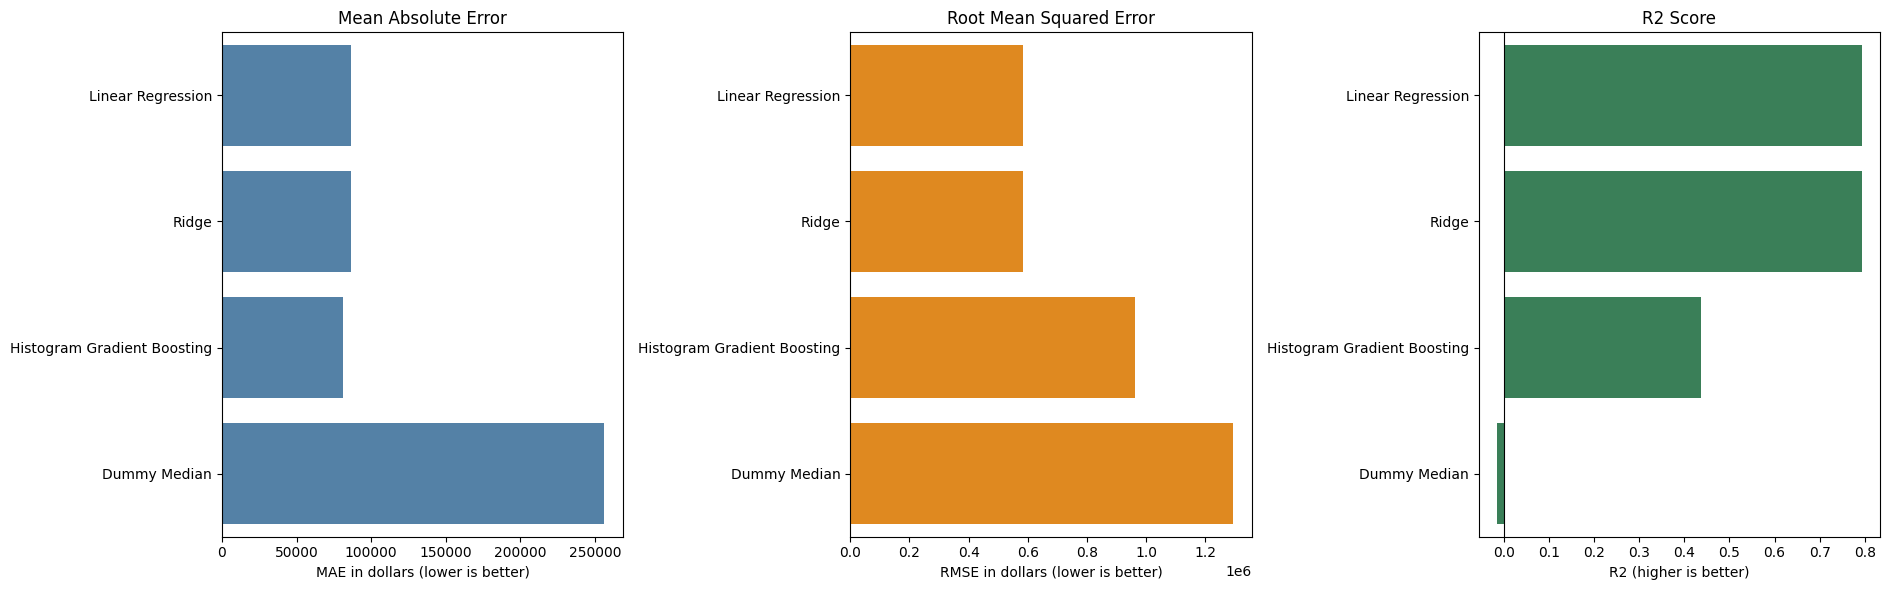

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

sns.barplot(data=model_results_df, x='MAE', y='Model', ax=axes[0], color='steelblue')
axes[0].set_title('Mean Absolute Error')
axes[0].set_xlabel('MAE in dollars (lower is better)')
axes[0].set_ylabel('')

sns.barplot(data=model_results_df, x='RMSE', y='Model', ax=axes[1], color='darkorange')
axes[1].set_title('Root Mean Squared Error')
axes[1].set_xlabel('RMSE in dollars (lower is better)')
axes[1].set_ylabel('')

sns.barplot(data=model_results_df, x='R2', y='Model', ax=axes[2], color='seagreen')
axes[2].set_title('R2 Score')
axes[2].set_xlabel('R2 (higher is better)')
axes[2].set_ylabel('')
axes[2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

### 4. Visualize the best model predictions

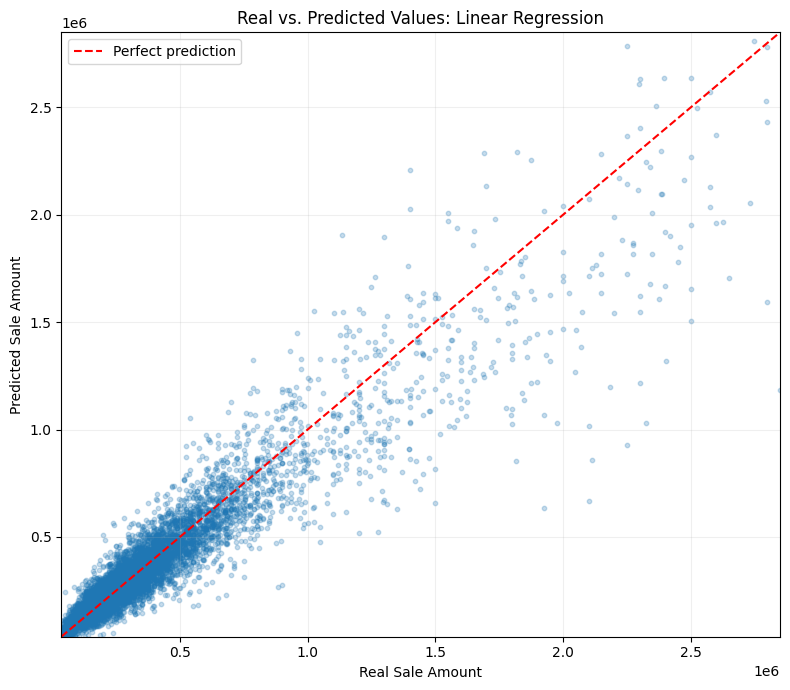

In [63]:
best_model_name = model_results_df.iloc[0]['Model']
best_predictions = model_predictions[best_model_name]

random_generator = np.random.default_rng(77)
sample_indices = random_generator.choice(
    len(y_test_clean),
    size=min(10_000, len(y_test_clean)),
    replace=False
)
real_sample = y_test_clean.to_numpy()[sample_indices]
predicted_sample = best_predictions[sample_indices]

lower_limit = min(
    np.quantile(real_sample, 0.01),
    np.quantile(predicted_sample, 0.01)
)
upper_limit = max(
    np.quantile(real_sample, 0.99),
    np.quantile(predicted_sample, 0.99)
)

plt.figure(figsize=(8, 7))
plt.scatter(real_sample, predicted_sample, alpha=0.25, s=10)
plt.plot(
    [lower_limit, upper_limit],
    [lower_limit, upper_limit],
    '--',
    color='red',
    label='Perfect prediction'
)
plt.xlim(lower_limit, upper_limit)
plt.ylim(lower_limit, upper_limit)
plt.xlabel('Real Sale Amount')
plt.ylabel('Predicted Sale Amount')
plt.title(f'Real vs. Predicted Values: {best_model_name}')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## General Conclusions

In this project, we followed the main phases of CRISP-DM, excluding deployment. The updated analysis first removes transactions marked with `Non Use Code`, because they may not represent normal market conditions for the preliminary negotiation-price use case.

* **Effect of the `Non Use Code` adjustment:** The filter removes 336,158 of the original 1,188,997 records (28.272401%) and leaves 852,839 observations for the saved model experiments. Both displayed modeling workflows contain 682,271 training rows and 170,568 test rows. These outputs describe the filtered market-sale population; they do not by themselves measure the causal improvement produced by the filter because the notebook does not show a controlled unfiltered comparison on identical indices.

* **Leakage prevention and feature selection:** `Sales Ratio` is excluded from the model predictors because it is calculated using `Sale Amount`. `List Year` is removed in the EDA-informed workflow because it is nearly redundant with `Year Recorded`, while `Serial Number` is removed because it is an identifier rather than a measured property characteristic.

* **Effect of EDA-informed preprocessing:** The minimally processed Linear Regression obtains MAE USD 92,053.54, RMSE USD 413,366.65, and R² 0.896053. EDA-informed Linear Regression obtains MAE USD 86,631.41, RMSE USD 582,703.66, and R² 0.7934. The MAE decreases by approximately 5.89%, but RMSE increases and R² decreases. Therefore, the logarithmic target and robust preprocessing improve the typical absolute error while producing larger errors for some expensive transactions; the preprocessing is not better under every metric.

* **Effect of model selection:** Histogram Gradient Boosting obtains the lowest MAE among the displayed models, USD 80,902.98. This is a 6.61% MAE reduction relative to EDA-informed Linear Regression and a 12.11% reduction relative to the minimally processed baseline. Nevertheless, its RMSE rises to USD 959,352.15 and its R² falls to 0.4401. Consequently, Histogram Gradient Boosting is the MAE-best experiment, while EDA-informed Linear Regression provides the best RMSE and R² among the clean models. It would be inaccurate to describe the tree model as universally superior.

* **Additional references:** EDA-informed Ridge produces MAE USD 86,624.17, RMSE USD 582,770.77, and R² 0.7934, which is almost identical to clean Linear Regression. The Dummy Median reference is substantially weaker, with MAE USD 256,164.34 and negative R², confirming that the trained models learn useful structure beyond a constant prediction.

* **Role of robust transformations:** The long upper tails of `Assessed Value` and `Sale Amount` support using `log1p` to compress scale differences and `RobustScaler` to reduce sensitivity to extreme numerical values. These techniques allow plausible high-value market observations to remain in the dataset instead of being discarded only because they cross a statistical threshold.

* **Remaining execution limitations:** The saved output contains a `KeyError` from the old hardcoded deletion of index `375213`, which is no longer present after the `Non Use Code` filter. In addition, the exploratory `Sale Amount > 10000` objects are not passed to the saved model pipelines, so the reported model population remains 852,839 rows rather than 851,689. These cells should be cleaned before presenting the notebook as an error-free final workflow.

* **Business implications:** The models can support an initial price reference for Connecticut market transactions, but the higher errors for costly properties remain important. Predictions should support, not replace, professional appraisal. Future work should compare filtered and unfiltered populations under one fixed partition, remove the obsolete hardcoded deletion, apply every row rule before splitting, and evaluate temporal or property-segment validation.


# Automatic EDA

In [64]:
from ydata_profiling import ProfileReport

original_data = pd.read_csv("Real_Estate_Sales_2001-2024_GL_20260814.csv", low_memory=False)
profile = ProfileReport(original_data, title="Automatic EDA report")

profile.to_file("eda_report.html")

/tmp/ipykernel_8203/1288347595.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:14<00:00,  1.02s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Using `ydata-profiling` as an automatic EDA tool is really useful for getting the big picture of the data quickly. With a single line of code it generates a full HTML report with an overview of the dataset and a section for each variable.

For numeric variables it shows:
- Inferred type
- Distinct count
- Missing count
- Infinite count
- Memory size
- Mean, minimum and maximum
- Zeros and negative counts
- A histogram of the distribution

For categorical / text variables it only shows the metrics that make sense for them (distinct count, missing count, memory size) plus the most frequent values, since statistics like mean or minimum do not apply.

It is also very intuitive thanks to the alert system. In this case, `Non Use Code` is only filled for sales that should not be used as market references, so the library detected that around 71% of the rows had a missing value in that column and highlighted it in red. It does the same for other issues, labeling each variable when it finds high correlation, skewness or many missing values.

The report also includes sections beyond the individual variables: a correlation matrix, a missing values map, and a sample of the first and last rows.

On the other hand, the tool is not a replacement for manual analysis. It gives a general view of each variable, but disaggregated metrics, boxplots, and domain-specific checks still need to be done by hand.

# Bonus: Doing PCA

In [65]:
y = data['Sale Amount']
X = data.drop(columns=['Sale Amount','Sales Ratio', 'Serial Number' , 'Town', 'Property Type' ,'Residential Type'])

X['Year Recorded'] = X['Year Recorded'].ffill()
X['Month Recorded'] = X['Month Recorded'].ffill()
X['Day Recorded'] = X['Day Recorded'].ffill()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

In [66]:
from sklearn.decomposition import PCA

numeric_columns = logarithmic_columns + remaining_numerical_columns

pca_pipeline = Pipeline(steps=[
    ('prep', ColumnTransformer(transformers=[
        ('assessed_value_log', logarithmic_pipeline, logarithmic_columns),
        ('numerical', numerical_pipeline, remaining_numerical_columns),
    ])),
    ('pca', PCA(n_components=0.8, random_state=42)),
])

X_pca = pca_pipeline.fit_transform(X_train)
X_test_pca = pca_pipeline.transform(X_test)

pca = pca_pipeline["pca"]
resumen = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(pca.n_components_)],
    "Varianza explicada": pca.explained_variance_ratio_,
    "Acumulada": np.cumsum(pca.explained_variance_ratio_),
})
print(resumen)


  Componente  Varianza explicada  Acumulada
0        PC1            0.515059   0.515059
1        PC2            0.182683   0.697742
2        PC3            0.167536   0.865278


In [67]:
feature_names = pca_pipeline.named_steps["prep"].get_feature_names_out()

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print(loadings)

                                         PC1       PC2       PC3
assessed_value_log__Assessed Value  0.985370  0.014448  0.017928
numerical__Year Recorded            0.169875 -0.011096 -0.138723
numerical__Month Recorded           0.009828 -0.344381  0.930198
numerical__Day Recorded            -0.009553  0.938653  0.339363


## Aplying everything

In [68]:
y = data['Sale Amount']
X = data.drop(columns=['Sale Amount','Sales Ratio', 'List Year', 'Serial Number'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

numeric_columns = logarithmic_columns + remaining_numerical_columns

numeric_pca_branch = Pipeline(steps=[
    ('prep', ColumnTransformer(transformers=[
        ('assessed_value_log', logarithmic_pipeline, logarithmic_columns),
        ('numerical', numerical_pipeline, remaining_numerical_columns),
    ])),
    ('pca', PCA(n_components=0.8, random_state=42)),
])

eda_preprocessing = ColumnTransformer(
    transformers=[
        ('town_binary', town_binary_pipeline, binary_columns),
        ('categorical_one_hot', one_hot_pipeline, one_hot_columns),
        ('numeric_pca', numeric_pca_branch, numeric_columns),
    ],
    remainder='drop'
)

X_train_prep = eda_preprocessing.fit_transform(X_train)
X_test_prep  = eda_preprocessing.transform(X_test)

In [69]:
# Recover the names created by the preprocessing pipeline
final_feature_names = eda_preprocessing.get_feature_names_out()

# Convert only the first five transformed rows for visualization
if sparse.issparse(X_train_prep):
    X_train_pca_head = pd.DataFrame.sparse.from_spmatrix(
        X_train_prep[:5],
        columns=final_feature_names
    )
else:
    X_train_pca_head = pd.DataFrame(
        X_train_prep[:5],
        columns=final_feature_names
    )

# Display the transformed target beside the final feature matrix
final_dataset_preview = X_train_pca_head.copy()
final_dataset_preview['target__Sale Amount_log1p'] = (
    y_train_eda.to_numpy()[:5]
)

print('Final training dataset preview:')
display(final_dataset_preview)
print('Final number of predictor columns:', X_train_pca_head.shape[1])

Final training dataset preview:


,town_binary__Town_binary_0,town_binary__Town_binary_1,town_binary__Town_binary_2,town_binary__Town_binary_3,town_binary__Town_binary_4,town_binary__Town_binary_5,town_binary__Town_binary_6,town_binary__Town_binary_7,categorical_one_hot__Property Type_Apartments,categorical_one_hot__Property Type_Commercial,...,categorical_one_hot__Property Type_Vacant Land,categorical_one_hot__Residential Type_Condo,categorical_one_hot__Residential Type_Four Family,categorical_one_hot__Residential Type_Single Family,categorical_one_hot__Residential Type_Three Family,categorical_one_hot__Residential Type_Two Family,numeric_pca__pca0,numeric_pca__pca1,numeric_pca__pca2,target__Sale Amount_log1p
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.593104,-0.747815,-0.364570,13.180634
1,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.281333,-0.591782,-0.102567,13.681980
2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-1.231732,0.337069,-0.319981,11.736077
3,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.429446,0.160210,0.861469,12.736704
4,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.288450,0.241832,-0.998786,12.644008


Final number of predictor columns: 27


In [70]:
model_results_pca = []
model_predictions_pca = {}
trained_models_pca = {}

for model_name, model in linear_models.items():
    result, predictions = fit_and_evaluate_model(
        model_name, model, X_train_prep, X_test_prep
    )
    model_results_pca.append(result)
    model_predictions_pca[model_name] = predictions
    trained_models_pca[model_name] = model
    print(f'{model_name} completed in {result["Training Time (s)"]:.2f} seconds.')

Dummy Median completed in 0.01 seconds.
Linear Regression completed in 0.37 seconds.
Ridge completed in 0.38 seconds.


In [71]:
# HistGradientBoosting requires dense input
X_train_tree = (
    X_train_prep.toarray() if sparse.issparse(X_train_prep) else X_train_prep
)
X_test_tree = (
    X_test_prep.toarray() if sparse.issparse(X_test_prep) else X_test_prep
)

result, predictions = fit_and_evaluate_model(
    'Histogram Gradient Boosting',
    hist_gradient_boosting,
    X_train_tree,
    X_test_tree
)

model_results_pca.append(result)
model_predictions_pca['Histogram Gradient Boosting'] = predictions
trained_models_pca['Histogram Gradient Boosting'] = hist_gradient_boosting
print(
    'Histogram Gradient Boosting completed in '
    f'{result["Training Time (s)"]:.2f} seconds.'
)

Histogram Gradient Boosting completed in 4.07 seconds.


In [72]:
model_results_df_pca = (
    pd.DataFrame(model_results_pca)
    .sort_values('RMSE')
    .reset_index(drop=True)
)
display(
    model_results_df_pca.style.format({
        'MAE': '${:,.2f}',
        'RMSE': '${:,.2f}',
        'R2': '{:.4f}',
        'Training Time (s)': '{:.2f}'
    })
)

,Model,MAE,RMSE,R2,Training Time (s)
0,Ridge,"$100,542.94","$694,617.62",0.7065,0.38
1,Linear Regression,"$100,541.42","$694,821.82",0.7063,0.37
2,Histogram Gradient Boosting,"$95,040.71","$966,955.16",0.4312,4.07
3,Dummy Median,"$256,164.34","$1,292,179.82",-0.0158,0.01


As we can see, every model lost some accuracy when trained using only 3 principal components. In general, the benefit of this dimensionality reduction lies in training and inference time: by summarizing the information of 4 columns into 3, each model has less data to process during training and fewer parameters to compute when making predictions. In this case, however, going from 4 to 3 features is too small a reduction for that gain to be noticeable.

Overall, this dataset does not have enough columns to demonstrate the real power of PCA, but it works as a simple approach to the technique. On larger datasets with many more variables, PCA can compress the information at an acceptable cost in accuracy.